## Библиотеки

In [143]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from datasets import load_dataset
from scipy.sparse import hstack

import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import hashlib
from sklearn.svm import LinearSVC
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import csr_matrix
from scipy.special import expit

**Структура ноутбука**:
- Загрузка данных (Скачиваем датасет и разбиваем его на train, val и test, используя фиксированные индексы)
- EDA (Проводим разведочный анализ: смотрим на распределение классов, длины текстов и языки)
- Baseline (TF-IDF). Строим простую модель на основе TF-IDF и линейного классификатора. Это наша точка отсчёта, с которой мы сравниваем все остальные методы
- Transformers (BERT)
- Улучшение Baseline (Добавляем дополнительные признаки (символьные n-граммы, язык, длина текста), чтобы выжать максимум из классического подхода)
- Confidence Analysis (Анализируем уверенность модели в предсказаниях)
- Итоги

**Главный вывод (спойлер)**

> **Классический TF-IDF + LinearSVC победил трансформеры** на этой задаче. Так как для маршрутизации важны ключевые слова (коды ошибок, названия продуктов), а не глубокая семантика. TF-IDF ловит их точнее и быстрее.


## Загрузка датасета + фиксированные индексы

In [24]:
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

df = dataset["train"].to_pandas()

In [25]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


### фиксированные split индексы

In [26]:
def load_idx(path):
    with open(path) as f:
        return [int(x.strip()) for x in f]

In [27]:
train_idx = load_idx("train_idx.txt")
val_idx = load_idx("val_idx.txt")
test_idx = load_idx("test_idx.txt")

In [28]:
df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

In [29]:
assert len(df_train) == 49412, f"Train size mismatch: {len(df_train)}"
assert len(df_val) == 6176, f"Val size mismatch: {len(df_val)}"
assert len(df_test) == 6177, f"Test size mismatch: {len(df_test)}"

print("Данные загружены и разбиты корректно!")
print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Данные загружены и разбиты корректно!
Train: 49412, Val: 6176, Test: 6177


### подготовка текста

In [31]:
def prepare_text(row):
    subject = str(row['subject']) if pd.notna(row['subject']) else ""
    body = str(row['body']) if pd.notna(row['body']) else ""
    return f"{subject} [SEP] {body}"

In [32]:
df_train['text'] = df_train.apply(prepare_text, axis=1)
df_val['text'] = df_val.apply(prepare_text, axis=1)
df_test['text'] = df_test.apply(prepare_text, axis=1)

In [33]:
df_train["type"] = df_train["type"].fillna("Unknown")
df_val["type"] = df_val["type"].fillna("Unknown")
df_test["type"] = df_test["type"].fillna("Unknown")

## EDA

In [56]:
df_train['char_len'] = df_train['text'].str.len()
df_train['word_len'] = df_train['text'].str.split().map(len)

df_val['char_len'] = df_val['text'].str.len()
df_val['word_len'] = df_val['text'].str.split().map(len)

df_test['char_len'] = df_test['text'].str.len()
df_test['word_len'] = df_test['text'].str.split().map(len)

In [57]:
def missing_values(df, name):
    print(f"=== Missing values: {name} ===")
    display(df.isna().mean().sort_values(ascending=False))

missing_values(df_train, "Train")
missing_values(df_val, "Val")
missing_values(df_test, "Test")

=== Missing values: Train ===


,0
tag_8,0.959909
tag_7,0.903728
tag_6,0.785882
tag_5,0.552376
version,0.536064
tag_4,0.287380
tag_3,0.216344
tag_2,0.213612
answer,0.212884
tag_1,0.212661


=== Missing values: Val ===


,0
tag_8,0.960006
tag_7,0.903174
tag_6,0.787079
tag_5,0.556995
version,0.547118
tag_4,0.294203
tag_3,0.227170
tag_2,0.224093
tag_1,0.223446
answer,0.223446


=== Missing values: Test ===


,0
tag_8,0.960499
tag_7,0.900761
tag_6,0.784685
tag_5,0.549620
version,0.536021
tag_4,0.284604
tag_3,0.213048
tag_2,0.210134
tag_1,0.208839
answer,0.208839


Теги (`tag_1 ... tag_8`) почти полностью пустые. То есть признаки очень разреженные, скорее всего они не очень полезны

In [58]:
cols = ["subject", "body", "queue", "priority", "type", "language"]
for df_split, name in zip([df_train, df_val, df_test], ["Train", "Val", "Test"]):
    print(f"\n{name} dataset:")
    for c in cols:
        pct_missing = df_split[c].isna().mean()
        print(f"{c:10}: {pct_missing:.4f}")


Train dataset:
subject   : 0.0864
body      : 0.0000
queue     : 0.0000
priority  : 0.0000
type      : 0.0000
language  : 0.0000

Val dataset:
subject   : 0.0818
body      : 0.0000
queue     : 0.0000
priority  : 0.0000
type      : 0.0000
language  : 0.0000

Test dataset:
subject   : 0.0852
body      : 0.0000
queue     : 0.0000
priority  : 0.0000
type      : 0.0000
language  : 0.0000


Целевые переменные полностью заполнены

In [59]:
def md5_hash(text):
    return hashlib.md5(text.encode("utf-8", errors="ignore")).hexdigest()

hashes_train = set(df_train['text'].map(md5_hash))
hashes_val = set(df_val['text'].map(md5_hash))
hashes_test = set(df_test['text'].map(md5_hash))

print("Duplicate rate in Train:", 1 - len(hashes_train)/len(df_train))
print("Duplicate rate in Val:", 1 - len(hashes_val)/len(df_val))
print("Duplicate rate in Test:", 1 - len(hashes_test)/len(df_test))

print("Cross-split duplicates:")
print("Train ∩ Val:", len(hashes_train & hashes_val))
print("Train ∩ Test:", len(hashes_train & hashes_test))
print("Val ∩ Test:", len(hashes_val & hashes_test))


Duplicate rate in Train: 0.13484578644863598
Duplicate rate in Val: 0.13180051813471505
Duplicate rate in Test: 0.13420754411526636
Cross-split duplicates:
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


13–14% тикетов повторяются внутри датасета. Это нормально для support-систем, потому что пользователи часто задают одинаковые вопросы / одинаковые шаблонные письма
Также видим, что нет утечки данных между сплитами

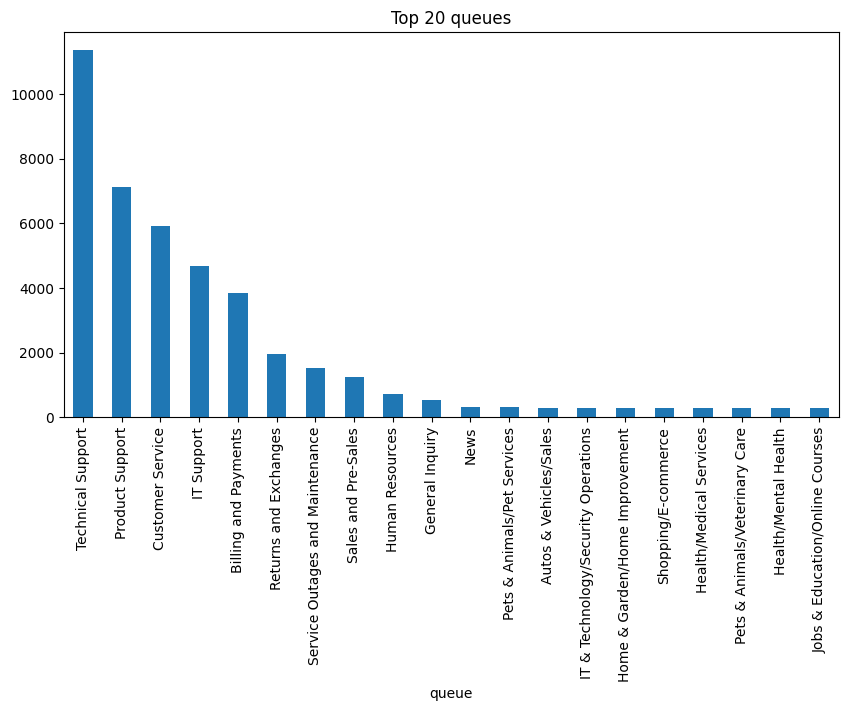

In [60]:
plt.figure(figsize=(10,5))
df_train["queue"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 queues")
plt.show()

Наблюдается сильный дисбаланс классов. Наиболее крупные категории — Technical Support, Product Support и Customer Service, которые содержат несколько тысяч тикетов. В то же время многие очереди имеют всего около 200–300

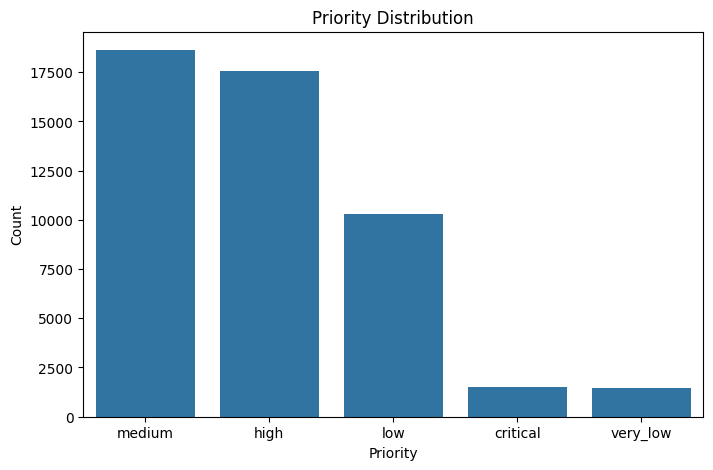


Priority proportions:


,proportion
priority,
medium,0.377014
high,0.355096
low,0.208047
critical,0.030681
very_low,0.029163


In [61]:
priority_counts = df_train["priority"].value_counts()

plt.figure(figsize=(8,5))
sns.countplot(
    data=df_train,
    x="priority",
    order=priority_counts.index
)

plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

print("\nPriority proportions:")
display(df_train["priority"].value_counts(normalize=True))


Распределение `priority` показывает, что большинство тикетов относятся к категориям `medium` (37.7%) и `high` (35.5%). Менее срочные обращения (`low`) составляют около 20% данных, тогда как крайние значения — `critical` и `very_low` — встречаются значительно реже (около 3% каждый)

In [62]:
df_train.groupby("priority")["char_len"].mean()

,char_len
priority,
critical,596.850923
high,455.210019
low,472.567802
medium,463.453594
very_low,574.532269


Критические тикеты длиннее.Когда проблема серьёзная, пользователь обычно подробно описывает проблему и  добавляет больше деталей \
Интересный момент: `very_low` тоже длинный. Возможно, что такие тикеты — длинные обсуждения или вопросы, но не срочные.

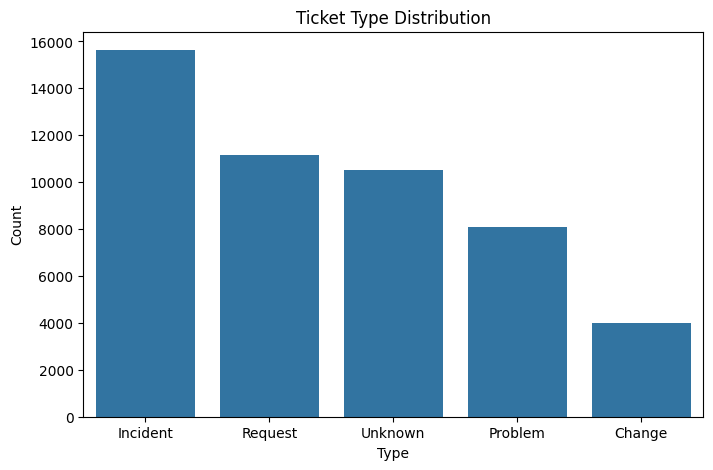


Type proportions:


,proportion
type,
Incident,0.316360
Request,0.225957
Unknown,0.212661
Problem,0.163989
Change,0.081033


In [63]:
type_counts = df_train["type"].value_counts()

plt.figure(figsize=(8,5))
sns.countplot(
    data=df_train,
    x="type",
    order=type_counts.index
)

plt.title("Ticket Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

print("\nType proportions:")
display(df_train["type"].value_counts(normalize=True))


Наиболее распространённым типом тикетов является `Incident` (31.6%), что означает сообщения о возникших проблемах или сбоях. Далее следуют `Request` (22.6%) — запросы на выполнение определённых действий или получение информации

Интересно, что значительная доля тикетов имеет тип `Unknown` (21.3%), что может указывать на случаи, когда обращение сложно автоматически классифицировать или оно содержит недостаточно структурированное описание проблемы

Категории `Problem` и `Change` встречаются реже, что соответствует тому, что такие обращения обычно требуют более специализированной обработки.

In [64]:
df_train.groupby("type")["char_len"].mean()


,char_len
type,
Change,482.570430
Incident,424.955796
Problem,421.467234
Request,449.945902
Unknown,589.798249


Самый длинный текст  - категория `Unknown`. Это может указывать на плохо структурированные запросы, которые сложнее классифицировать.

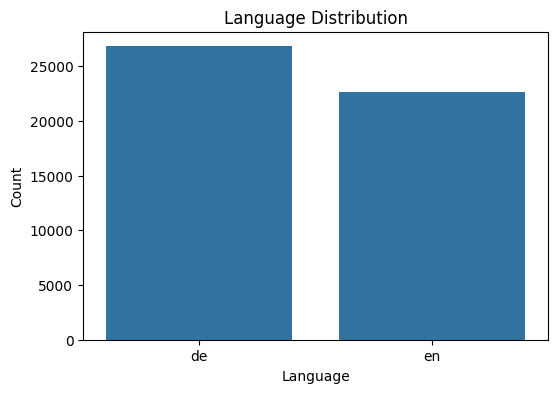

Language distribution:


,count
language,
de,26799
en,22613



Language proportions:


,proportion
language,
de,0.542358
en,0.457642


In [65]:
language_counts = df_train["language"].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(
    data=df_train,
    x="language",
    order=language_counts.index
)

plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

print("Language distribution:")
display(language_counts)

print("\nLanguage proportions:")
display(df_train["language"].value_counts(normalize=True))


Датасет двуязычный. Около 54% тикетов написаны на немецком языке и 46% — на английском

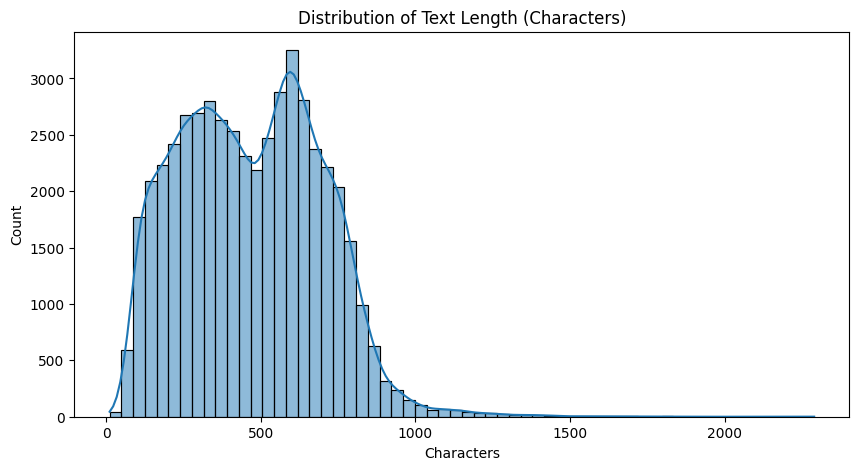

Character length statistics:


,char_len
count,49412.000000
mean,469.754635
std,226.844163
min,11.000000
25%,285.000000
50%,465.000000
75%,639.000000
max,2290.000000


In [66]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_train["char_len"],
    bins=60,
    kde=True
)

plt.title("Distribution of Text Length (Characters)")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

print("Character length statistics:")
display(df_train["char_len"].describe())


Средняя длина текста тикета составляет примерно 470 символов, при медиане 465 символов. Большинство сообщений находится в диапазоне от 285 до 639 символов.

Минимальная длина текста — всего 11 символов, тогда как максимальная достигает 2290 символов

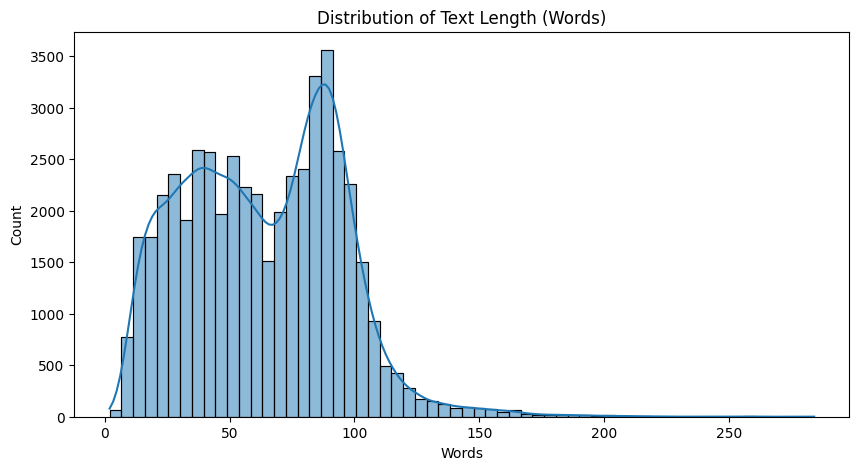

Word length statistics:


,word_len
count,49412.000000
mean,63.445438
std,31.205693
min,2.000000
25%,38.000000
50%,63.000000
75%,88.000000
max,284.000000


In [67]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_train["word_len"],
    bins=60,
    kde=True
)

plt.title("Distribution of Text Length (Words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

print("Word length statistics:")
display(df_train["word_len"].describe())

В среднем тикет содержит около 63 слов. Половина тикетов имеет длину около 63 слов, а 75% сообщений содержат менее 88 слов.

При этом некоторые тикеты могут быть достаточно длинными — до 284 слов.

In [68]:
df_train["subject_len"] = df_train["subject"].fillna("").str.len()
df_train["body_len"] = df_train["body"].fillna("").str.len()

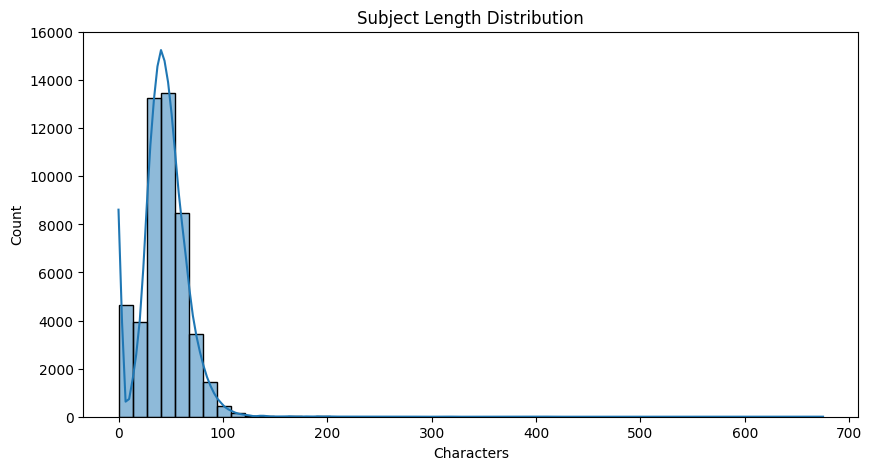

Subject length statistics:


,subject_len
count,49412.000000
mean,43.347648
std,23.211045
min,0.000000
25%,31.000000
50%,43.000000
75%,56.000000
max,675.000000


In [69]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_train["subject_len"],
    bins=50,
    kde=True
)

plt.title("Subject Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

print("Subject length statistics:")
display(df_train["subject_len"].describe())


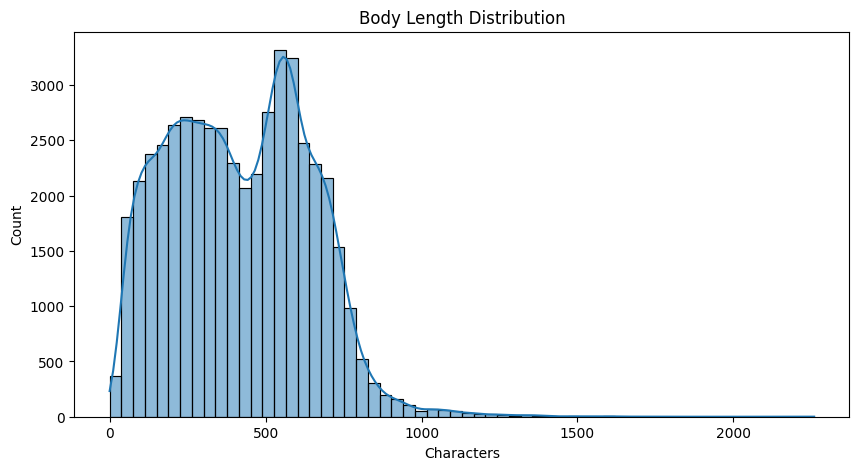

Body length statistics:


,body_len
count,49412.000000
mean,419.406986
std,223.607335
min,0.000000
25%,233.000000
50%,415.000000
75%,587.000000
max,2259.000000


In [70]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_train["body_len"],
    bins=60,
    kde=True
)

plt.title("Body Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

print("Body length statistics:")
display(df_train["body_len"].describe())


Средняя длина поля `subject` составляет около 43 символов

В то же время основная информация содержится в поле `body`, средняя длина которого составляет около 419 символов.

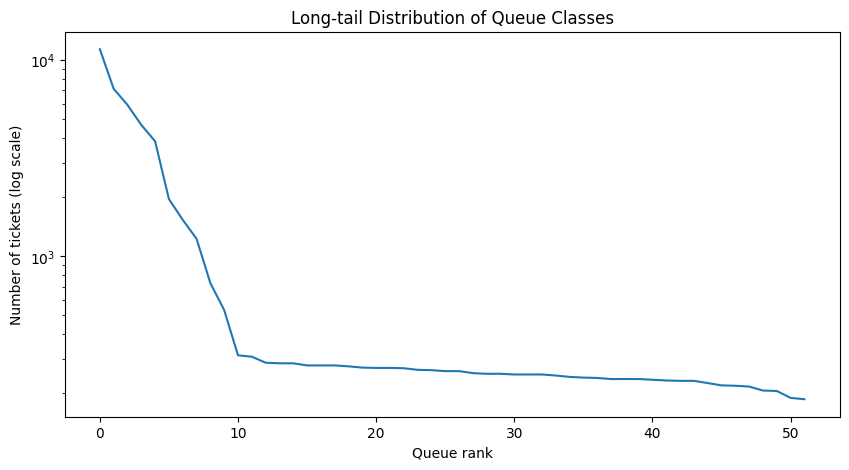

Queue statistics:


,count
count,52.000000
mean,950.230769
std,2056.279265
min,187.000000
25%,237.000000
50%,260.000000
75%,285.500000
max,11354.000000



Smallest classes:


,count
queue,
Food & Drink/Restaurants,232
Books & Literature/Fiction,232
Shopping/Retail Stores,226
People & Society/Culture & Society,220
IT & Technology/Hardware Support,219
Home & Garden/Landscaping,217
Arts & Entertainment/Movies,207
IT & Technology/Software Development,206
Sports,190


In [71]:
queue_counts = df_train["queue"].value_counts()

plt.figure(figsize=(10,5))

plt.plot(sorted(queue_counts.values, reverse=True))
plt.yscale("log")

plt.title("Long-tail Distribution of Queue Classes")
plt.xlabel("Queue rank")
plt.ylabel("Number of tickets (log scale)")
plt.show()

print("Queue statistics:")
display(queue_counts.describe())

print("\nSmallest classes:")
display(queue_counts.tail(10))

У нас в датасете 52 класса, при этом среднее количество тикетов на класс составляет около 950, однако стандартное отклонение очень велико (≈2056)

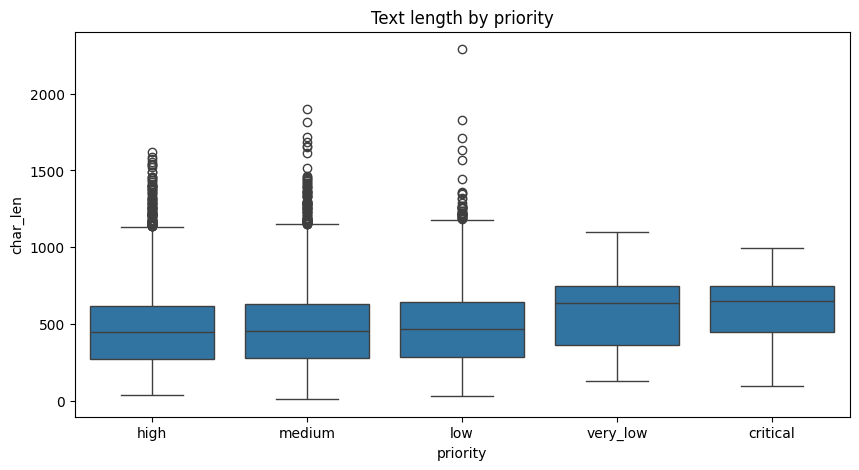

In [72]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_train, x="priority", y="char_len")
plt.title("Text length by priority")
plt.show()

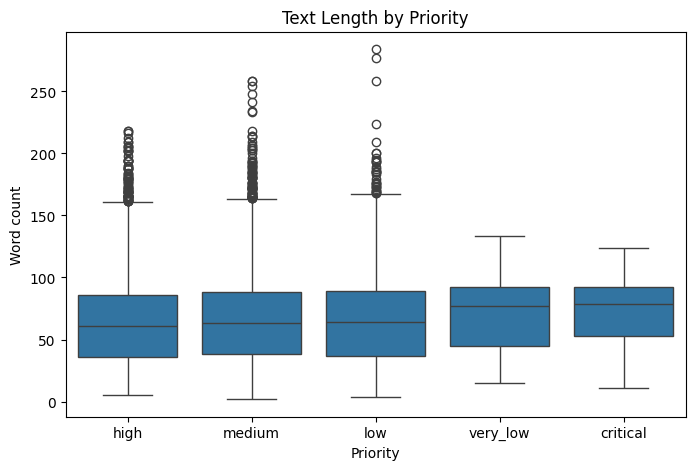

Average word length by priority:


,word_len
priority,
critical,72.254617
high,61.754417
low,64.142121
medium,63.419668
very_low,70.131159


In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_train,
    x="priority",
    y="word_len"
)

plt.title("Text Length by Priority")
plt.xlabel("Priority")
plt.ylabel("Word count")
plt.show()

print("Average word length by priority:")
display(df_train.groupby("priority")["word_len"].mean())

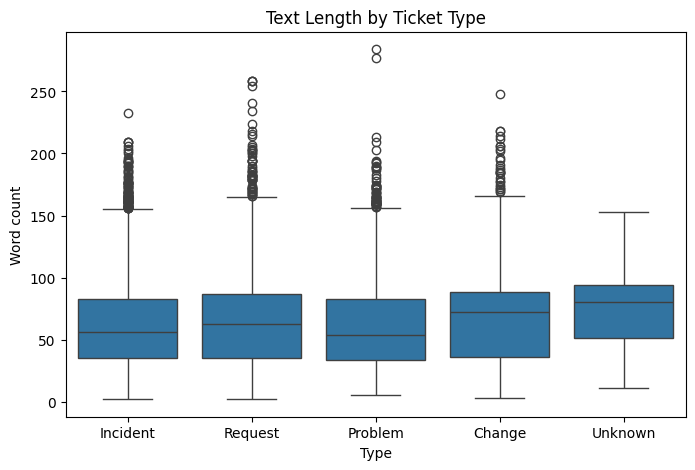

Average word length by type:


,word_len
type,
Change,65.772727
Incident,59.238997
Problem,58.602863
Request,62.835916
Unknown,73.198135


In [75]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_train,
    x="type",
    y="word_len"
)

plt.title("Text Length by Ticket Type")
plt.xlabel("Type")
plt.ylabel("Word count")
plt.show()

print("Average word length by type:")
display(df_train.groupby("type")["word_len"].mean())

## Baseline: TF-IDF + линейная модель

Baseline у Четвергова:
Score = 0.8674  

### Первые шаги

In [76]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3
)

In [77]:
X_train = vectorizer.fit_transform(df_train["text"])
X_val = vectorizer.transform(df_val["text"])

In [78]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, df_train["queue"])

LogisticRegression(max_iter=1000)

In [79]:
val_pred = model.predict(X_val)

f1 = f1_score(df_val["queue"], val_pred, average="macro")
acc = accuracy_score(df_val["queue"], val_pred)

print("Macro F1:", f1)
print("Accuracy:", acc)


Macro F1: 0.7409553598236217
Accuracy: 0.572538860103627


У нас по EDA выяснилось, что сильный дисбаланс, попробуем с балансировкой модель

In [80]:
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)


In [81]:
model.fit(X_train, df_train["queue"])

LogisticRegression(class_weight='balanced', max_iter=2000, n_jobs=-1)

In [82]:
val_pred = model.predict(X_val)

f1 = f1_score(df_val["queue"], val_pred, average="macro")
acc = accuracy_score(df_val["queue"], val_pred)

print("Macro F1:", f1)
print("Accuracy:", acc)


Macro F1: 0.801974372226369
Accuracy: 0.4956282383419689


Пробуем увеличить tf-idf пространство, пока зацикливаемся на метрике F1, она дает наибольший вес в итоговой метрике

In [83]:
vectorizer = TfidfVectorizer(
    max_features=150000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

In [84]:
X_train = vectorizer.fit_transform(df_train["text"])
X_val = vectorizer.transform(df_val["text"])


In [85]:
model.fit(X_train, df_train["queue"])

LogisticRegression(class_weight='balanced', max_iter=2000, n_jobs=-1)

In [86]:
val_pred = model.predict(X_val)

f1 = f1_score(df_val["queue"], val_pred, average="macro")
acc = accuracy_score(df_val["queue"], val_pred)

print("Macro F1:", f1)
print("Accuracy:", acc)

Macro F1: 0.8285914243567808
Accuracy: 0.5119818652849741


Попробуем добавить **char n-grams**

In [87]:
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    min_df=3,
    max_features=50000
)

In [88]:
X_train_word = vectorizer.fit_transform(df_train["text"])
X_val_word = vectorizer.transform(df_val["text"])

X_train_char = char_vectorizer.fit_transform(df_train["text"])
X_val_char = char_vectorizer.transform(df_val["text"])

X_train = hstack([X_train_word, X_train_char])
X_val = hstack([X_val_word, X_val_char])


In [89]:
model.fit(X_train, df_train["queue"])

LogisticRegression(class_weight='balanced', max_iter=2000, n_jobs=-1)

In [90]:
val_pred = model.predict(X_val)

f1 = f1_score(df_val["queue"], val_pred, average="macro")
acc = accuracy_score(df_val["queue"], val_pred)

print("Macro F1:", f1)
print("Accuracy:", acc)

Macro F1: 0.8601303134038265
Accuracy: 0.5395077720207254


Попробуем LinearSVC

In [92]:
model = LinearSVC(class_weight="balanced")
model.fit(X_train, df_train["queue"])

LinearSVC(class_weight='balanced')

In [93]:
val_pred = model.predict(X_val)

f1 = f1_score(df_val["queue"], val_pred, average="macro")
acc = accuracy_score(df_val["queue"], val_pred)

print("Macro F1:", f1)
print("Accuracy:", acc)

Macro F1: 0.8952080074877518
Accuracy: 0.6606217616580311


Чтобы не париться дальше, напишем функциию, которая считает итоговую метрику

In [98]:
def evaluate_ticket_routing(
    y_queue_true,
    y_queue_pred,
    y_priority_true,
    y_priority_pred,
    y_type_true,
    y_type_pred,
    verbose=True,
):

    macro_f1_queue = f1_score(y_queue_true, y_queue_pred, average="macro")
    acc_queue = accuracy_score(y_queue_true, y_queue_pred)

    acc_priority = accuracy_score(y_priority_true, y_priority_pred)
    acc_type = accuracy_score(y_type_true, y_type_pred)

    score = (
        0.70 * macro_f1_queue
        + 0.15 * acc_priority
        + 0.15 * acc_type
    )

    if verbose:
        print(f"MacroF1(queue):   {macro_f1_queue:.4f}")
        print(f"Acc(queue):       {acc_queue:.4f}")
        print(f"Acc(priority):    {acc_priority:.4f}")
        print(f"Acc(type):        {acc_type:.4f}")
        print(f"Final score:      {score:.4f}")

    return {
        "macro_f1_queue": macro_f1_queue,
        "acc_queue": acc_queue,
        "acc_priority": acc_priority,
        "acc_type": acc_type,
        "score": score,
    }

Пока лучший результат

In [99]:
vectorizer = TfidfVectorizer(
    max_features=150000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    min_df=3,
    max_features=50000
)

In [100]:
X_train_word = vectorizer.fit_transform(df_train["text"])
X_val_word = vectorizer.transform(df_val["text"])

X_train_char = char_vectorizer.fit_transform(df_train["text"])
X_val_char = char_vectorizer.transform(df_val["text"])

X_train = hstack([X_train_word, X_train_char])
X_val = hstack([X_val_word, X_val_char])

In [101]:
model = LinearSVC(class_weight="balanced")
model_priority = LinearSVC(class_weight="balanced")
model_type = LinearSVC(class_weight="balanced")

In [102]:
model.fit(X_train, df_train["queue"])
model_priority.fit(X_train, df_train["priority"])
model_type.fit(X_train, df_train["type"])

LinearSVC(class_weight='balanced')

In [103]:
queue_pred = model.predict(X_val)
priority_pred = model_priority.predict(X_val)
type_pred = model_type.predict(X_val)

In [104]:
results = evaluate_ticket_routing(
    df_val["queue"],
    queue_pred,
    df_val["priority"],
    priority_pred,
    df_val["type"],
    type_pred
)

MacroF1(queue):   0.8952
Acc(queue):       0.6606
Acc(priority):    0.7137
Acc(type):        0.8896
Final score:      0.8671


Чуть ниже baseline Четвергова, попробуем настроить гиперпараметры

In [105]:
vectorizer = TfidfVectorizer(
    max_features=200000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2,5),
    min_df=3,
    max_features=80000
)

X_train_word = vectorizer.fit_transform(df_train["text"])
X_val_word = vectorizer.transform(df_val["text"])

X_train_char = char_vectorizer.fit_transform(df_train["text"])
X_val_char = char_vectorizer.transform(df_val["text"])


X_train = hstack([X_train_word, X_train_char])
X_val = hstack([X_val_word, X_val_char])

model = LinearSVC(
    C=2,
    class_weight="balanced",
    max_iter=5000
)

In [106]:
for C in [0.5, 1, 2, 3]:

    model = LinearSVC(
        C=C,
        class_weight="balanced",
        max_iter=5000
    )

    model.fit(X_train, df_train["queue"])

    pred = model.predict(X_val)

    f1 = f1_score(df_val["queue"], pred, average="macro")

    print("C =", C, "MacroF1 =", f1)

C = 0.5 MacroF1 = 0.8845844805992946
C = 1 MacroF1 = 0.8970611715132863
C = 2 MacroF1 = 0.9058969484130738
C = 3 MacroF1 = 0.9102363122710926


Будем использовать C=3

In [107]:
model = LinearSVC(
    C=3,
    class_weight="balanced",
    max_iter=5000
)

model_priority = LinearSVC(
    C=3,
    class_weight="balanced",
    max_iter=5000
)

model_type = LinearSVC(
    C=3,
    class_weight="balanced",
    max_iter=5000
)


In [108]:
model.fit(X_train, df_train["queue"])
model_priority.fit(X_train, df_train["priority"])
model_type.fit(X_train, df_train["type"])

LinearSVC(C=3, class_weight='balanced', max_iter=5000)

In [109]:
queue_pred = model.predict(X_val)
priority_pred = model_priority.predict(X_val)
type_pred = model_type.predict(X_val)

In [110]:
results = evaluate_ticket_routing(
    df_val["queue"],
    queue_pred,
    df_val["priority"],
    priority_pred,
    df_val["type"],
    type_pred
)

MacroF1(queue):   0.9102
Acc(queue):       0.6919
Acc(priority):    0.7290
Acc(type):        0.8949
Final score:      0.8807


Прогоним на тесте

In [111]:
X_test_word = vectorizer.transform(df_test["text"])
X_test_char = char_vectorizer.transform(df_test["text"])
X_test = hstack([X_test_word, X_test_char])

queue_pred_test = model.predict(X_test)
priority_pred_test = model_priority.predict(X_test)
type_pred_test = model_type.predict(X_test)

test_results = evaluate_ticket_routing(
    df_test["queue"], queue_pred_test,
    df_test["priority"], priority_pred_test,
    df_test["type"], type_pred_test
)


MacroF1(queue):   0.9111
Acc(queue):       0.6906
Acc(priority):    0.7235
Acc(type):        0.9009
Final score:      0.8814


Хороший результат, пока перейдем ко второму пункту базового минимума - Transformer multitask

## Transformer multitask

Попытки найти решение, которое побьет baseline

In [ ]:
MODEL_NAME = "bert-base-multilingual-cased"
MAX_LENGTH = 256
BATCH_SIZE = 32
EPOCHS_FROZEN = 1
EPOCHS_FINETUNE = 2
LR_HEAD = 1e-3
LR_BERT = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Для стабильности на Colab
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")

Device: cuda
Model: bert-base-multilingual-cased


In [ ]:
le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_train_priority = le_priority.fit_transform(df_train['priority'])
y_train_type = le_type.fit_transform(df_train['type'])

y_val_queue = le_queue.transform(df_val['queue'])
y_val_priority = le_priority.transform(df_val['priority'])
y_val_type = le_type.transform(df_val['type'])


In [ ]:
class TicketDataset(Dataset):
    def __init__(self, texts, labels_queue, labels_priority, labels_type, tokenizer, max_length):
        self.texts = texts
        self.labels_queue = labels_queue
        self.labels_priority = labels_priority
        self.labels_type = labels_type
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {key: val.squeeze() for key, val in encoding.items()}
        item['labels_queue'] = torch.tensor(self.labels_queue[idx], dtype=torch.long)
        item['labels_priority'] = torch.tensor(self.labels_priority[idx], dtype=torch.long)
        item['labels_type'] = torch.tensor(self.labels_type[idx], dtype=torch.long)
        return item

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = TicketDataset(
    df_train['text'].tolist(), y_train_queue, y_train_priority, y_train_type,
    tokenizer, MAX_LENGTH
)
val_dataset = TicketDataset(
    df_val['text'].tolist(), y_val_queue, y_val_priority, y_val_type,
    tokenizer, MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

In [ ]:
class MultiTaskBERT(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size

        self.dropout = nn.Dropout(0.3)

        self.head_queue = nn.Linear(hidden_size, n_queue)
        self.head_priority = nn.Linear(hidden_size, n_priority)
        self.head_type = nn.Linear(hidden_size, n_type)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)

        return {
            'queue': self.head_queue(cls_embedding),
            'priority': self.head_priority(cls_embedding),
            'type': self.head_type(cls_embedding)
        }

model = MultiTaskBERT(
    MODEL_NAME,
    n_queue=len(le_queue.classes_),
    n_priority=len(le_priority.classes_),
    n_type=len(le_type.classes_)
).to(DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_queue), y=y_train_queue)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion_queue = nn.CrossEntropyLoss(weight=class_weights)
criterion_priority = nn.CrossEntropyLoss()
criterion_type = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {'params': model.head_queue.parameters(), 'lr': LR_HEAD},
    {'params': model.head_priority.parameters(), 'lr': LR_HEAD},
    {'params': model.head_type.parameters(), 'lr': LR_HEAD},
    {'params': model.bert.parameters(), 'lr': LR_BERT},
])

# GradScaler для Mixed Precision
scaler = GradScaler()

/tmp/ipykernel_3060/2887694597.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
def train_epoch(model, loader, optimizer, scaler, epoch, frozen_bert=True):
    model.train()
    total_loss = 0

    if frozen_bert:
        model.bert.requires_grad_(False)
        model.head_queue.requires_grad_(True)
        model.head_priority.requires_grad_(True)
        model.head_type.requires_grad_(True)
    else:
        model.bert.requires_grad_(True)
        # Размораживаем последние 4 слоя BERT для стабильности
        for layer in model.bert.encoder.layer[:-4]:
            layer.requires_grad_(False)
        for layer in model.bert.encoder.layer[-4:]:
            layer.requires_grad_(True)

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids', None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)

        labels_q = batch['labels_queue'].to(DEVICE)
        labels_p = batch['labels_priority'].to(DEVICE)
        labels_t = batch['labels_type'].to(DEVICE)

        optimizer.zero_grad()

        # Mixed Precision
        # with autocast('cuda'):
        with autocast():
            outputs = model(input_ids, attention_mask, token_type_ids)

            loss = (0.70 * criterion_queue(outputs['queue'], labels_q) +
                    0.15 * criterion_priority(outputs['priority'], labels_p) +
                    0.15 * criterion_type(outputs['type'], labels_t))

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    status = "Frozen" if frozen_bert else "Fine-tuning"
    print(f"Epoch {epoch} [{status}]: Loss = {avg_loss:.4f}")
    return avg_loss

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_preds_q, all_true_q = [], []
    all_preds_p, all_true_p = [], []
    all_preds_t, all_true_t = [], []
    all_probs_q = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            token_type_ids = batch.get('token_type_ids', None)
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(DEVICE)

            outputs = model(input_ids, attention_mask, token_type_ids)

            # Queue
            probs_q = torch.softmax(outputs['queue'], dim=1)
            preds_q = torch.argmax(probs_q, dim=1)
            all_probs_q.extend(probs_q.max(dim=1).values.cpu().numpy())
            all_preds_q.extend(preds_q.cpu().numpy())
            all_true_q.extend(batch['labels_queue'].cpu().numpy())

            # Priority
            preds_p = torch.argmax(outputs['priority'], dim=1)
            all_preds_p.extend(preds_p.cpu().numpy())
            all_true_p.extend(batch['labels_priority'].cpu().numpy())

            # Type
            preds_t = torch.argmax(outputs['type'], dim=1)
            all_preds_t.extend(preds_t.cpu().numpy())
            all_true_t.extend(batch['labels_type'].cpu().numpy())

    macro_f1_q = f1_score(all_true_q, all_preds_q, average='macro')
    acc_q = accuracy_score(all_true_q, all_preds_q)
    acc_p = accuracy_score(all_true_p, all_preds_p)
    acc_t = accuracy_score(all_true_t, all_preds_t)

    score = 0.70 * macro_f1_q + 0.15 * acc_p + 0.15 * acc_t

    return {
        'macro_f1_queue': macro_f1_q,
        'acc_queue': acc_q,
        'acc_priority': acc_p,
        'acc_type': acc_t,
        'final_score': score,
        'probs_queue': np.array(all_probs_q),
        'preds_queue': np.array(all_preds_q),
        'true_queue': np.array(all_true_q)
    }

In [ ]:
print("Starting training...")
print("=" * 60)


for epoch in range(1, EPOCHS_FROZEN + 1):
    train_epoch(model, train_loader, optimizer, scaler, epoch, frozen_bert=True)


for epoch in range(EPOCHS_FROZEN + 1, EPOCHS_FROZEN + EPOCHS_FINETUNE + 1):
    train_epoch(model, train_loader, optimizer, scaler, epoch, frozen_bert=False)

print("=" * 60)
print("Training completed. Evaluating on validation set...")

Starting training...


/tmp/ipykernel_3060/3310739256.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 [Frozen]: Loss = 2.7944
Epoch 2 [Fine-tuning]: Loss = 1.0588
Epoch 3 [Fine-tuning]: Loss = 0.6556
Training completed. Evaluating on validation set...


In [ ]:
results = evaluate(model, val_loader)

print("\nValidation Results:")
print(f"MacroF1(queue):   {results['macro_f1_queue']:.4f}")
print(f"Acc(queue):       {results['acc_queue']:.4f}")
print(f"Acc(priority):    {results['acc_priority']:.4f}")
print(f"Acc(type):        {results['acc_type']:.4f}")
print(f"Final Score:      {results['final_score']:.4f}")


Validation Results:
MacroF1(queue):   0.8061
Acc(queue):       0.4720
Acc(priority):    0.5023
Acc(type):        0.8434
Final Score:      0.7661


Ну чтож, получили меньше baseline, давайте мб попробуем параметры поменять

In [ ]:
MODEL_NAME = "bert-base-multilingual-cased"
MAX_LENGTH = 256
BATCH_SIZE = 32
EPOCHS_FROZEN = 2
EPOCHS_FINETUNE = 4
LR_HEAD = 5e-4
LR_BERT = 1e-5
DROPOUT = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")
print(f"Total epochs: {EPOCHS_FROZEN + EPOCHS_FINETUNE}")


Device: cuda
Model: bert-base-multilingual-cased
Total epochs: 6


In [ ]:
print(f"\nПроверка данных:")
print(f"df_train size: {len(df_train)}")
print(f"df_val size: {len(df_val)}")
print(f"df_test size: {len(df_test)}")

if len(df_val) == 0:
    raise ValueError("df_val пуст. Проверьте загрузку индексов из data/*.txt")


Проверка данных:
df_train size: 49412
df_val size: 6176
df_test size: 6177


In [ ]:
class MultiTaskBERT(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size

        self.dropout = nn.Dropout(dropout)

        self.head_queue = nn.Linear(hidden_size, n_queue)
        self.head_priority = nn.Linear(hidden_size, n_priority)
        self.head_type = nn.Linear(hidden_size, n_type)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)

        return {
            'queue': self.head_queue(cls_embedding),
            'priority': self.head_priority(cls_embedding),
            'type': self.head_type(cls_embedding)
        }

model = MultiTaskBERT(
    MODEL_NAME,
    n_queue=len(le_queue.classes_),
    n_priority=len(le_priority.classes_),
    n_type=len(le_type.classes_),
    dropout=DROPOUT
).to(DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from torch.amp import autocast, GradScaler

class_weights = compute_class_weight('balanced', classes=np.unique(y_train_queue), y=y_train_queue)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion_queue = nn.CrossEntropyLoss(weight=class_weights)
criterion_priority = nn.CrossEntropyLoss()
criterion_type = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {'params': model.head_queue.parameters(), 'lr': LR_HEAD},
    {'params': model.head_priority.parameters(), 'lr': LR_HEAD},
    {'params': model.head_type.parameters(), 'lr': LR_HEAD},
    {'params': model.bert.parameters(), 'lr': LR_BERT},
])

scaler = GradScaler('cuda')

In [ ]:
def train_epoch(model, loader, optimizer, scaler, epoch, frozen_bert=True):
    model.train()
    total_loss = 0

    if frozen_bert:
        model.bert.requires_grad_(False)
        model.head_queue.requires_grad_(True)
        model.head_priority.requires_grad_(True)
        model.head_type.requires_grad_(True)
    else:
        model.bert.requires_grad_(True)
        # Размораживаем последние 4 слоя BERT для стабильности
        for layer in model.bert.encoder.layer[:-4]:
            layer.requires_grad_(False)
        for layer in model.bert.encoder.layer[-4:]:
            layer.requires_grad_(True)

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids', None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)

        labels_q = batch['labels_queue'].to(DEVICE)
        labels_p = batch['labels_priority'].to(DEVICE)
        labels_t = batch['labels_type'].to(DEVICE)

        optimizer.zero_grad()

        # Mixed Precision
        with autocast('cuda'):
        # with autocast():
            outputs = model(input_ids, attention_mask, token_type_ids)

            loss = (0.70 * criterion_queue(outputs['queue'], labels_q) +
                    0.15 * criterion_priority(outputs['priority'], labels_p) +
                    0.15 * criterion_type(outputs['type'], labels_t))

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    status = "Frozen" if frozen_bert else "Fine-tuning"
    print(f"Epoch {epoch} [{status}]: Loss = {avg_loss:.4f}")
    return avg_loss

In [ ]:
def analyze_confidence(true_labels, preds, probs, task_name="Queue"):
    sorted_idx = np.argsort(-probs)
    true_sorted = np.array(true_labels)[sorted_idx]
    preds_sorted = np.array(preds)[sorted_idx]
    probs_sorted = probs[sorted_idx]

    total_samples = len(true_labels)
    coverages = np.linspace(0.05, 1.0, 20)
    accuracies = []
    f1_scores = []

    for cov in coverages:
        n_samples = int(total_samples * cov)
        if n_samples == 0:
            continue
        acc = accuracy_score(true_sorted[:n_samples], preds_sorted[:n_samples])
        f1 = f1_score(true_sorted[:n_samples], preds_sorted[:n_samples], average='macro')
        accuracies.append(acc)
        f1_scores.append(f1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(coverages, accuracies, marker='o', label='Accuracy', linewidth=2)
    plt.plot(coverages, f1_scores, marker='s', label='Macro-F1', linewidth=2)
    plt.axhline(y=accuracies[-1], color='gray', linestyle='--', alpha=0.5, label='Full Test Acc')
    plt.xlabel('% данных (по уверенности)', fontsize=12)
    plt.ylabel('Метрика качества', fontsize=12)
    plt.title(f'Confidence Analysis: {task_name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(probs, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Уверенность модели (Probability)', fontsize=12)
    plt.ylabel('Количество тикетов', fontsize=12)
    plt.title('Распределение уверенности', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\n Вывод: {task_name}")
    print("=" * 80)
    print(f"{'Охват':<10} | {'Порог уверенности':<20} | {'Accuracy':<10} | {'Macro-F1':<10} | {'Гипотетическое качество':<25}")
    print("-" * 80)

    results = []
    for cov in [0.5, 0.7, 0.8, 0.9]:
        idx = int(total_samples * cov)
        if idx == 0:
            continue
        acc_auto = accuracy_score(true_sorted[:idx], preds_sorted[:idx])
        f1_auto = f1_score(true_sorted[:idx], preds_sorted[:idx], average='macro')
        thresh = probs_sorted[idx - 1]
        hypothetical_total = (cov * acc_auto) + ((1 - cov) * 1.0)

        print(f"{cov*100:<10.0f}% | {thresh:<20.4f} | {acc_auto:<10.4f} | {f1_auto:<10.4f} | {hypothetical_total:<25.4f}")
        results.append({'coverage': cov, 'acc': acc_auto, 'f1': f1_auto, 'hypothetical': hypothetical_total})


    return results

In [ ]:
print("\nЗапуск обучения...")
print("=" * 60)

for epoch in range(1, EPOCHS_FROZEN + 1):
    train_epoch(model, train_loader, optimizer, scaler, epoch, frozen_bert=True)

for epoch in range(EPOCHS_FROZEN + 1, EPOCHS_FROZEN + EPOCHS_FINETUNE + 1):
    train_epoch(model, train_loader, optimizer, scaler, epoch, frozen_bert=False)

print("=" * 60)
print("Обучение завершено. Оценка на validation set...")


Запуск обучения...
Epoch 1 [Frozen]: Loss = 2.8268
Epoch 2 [Frozen]: Loss = 2.6487
Epoch 3 [Fine-tuning]: Loss = 1.1021
Epoch 4 [Fine-tuning]: Loss = 0.6832
Epoch 5 [Fine-tuning]: Loss = 0.5650
Epoch 6 [Fine-tuning]: Loss = 0.5121
Обучение завершено. Оценка на validation set...


In [ ]:
results = evaluate(model, val_loader)

print("\nРезультаты Validation:")
print(f"MacroF1(queue):   {results['macro_f1_queue']:.4f}")
print(f"Acc(queue):       {results['acc_queue']:.4f}")
print(f"Acc(priority):    {results['acc_priority']:.4f}")
print(f"Acc(type):        {results['acc_type']:.4f}")
print(f"Final Score:      {results['final_score']:.4f}")



Результаты Validation:
MacroF1(queue):   0.8121
Acc(queue):       0.3977
Acc(priority):    0.5295
Acc(type):        0.8429
Final Score:      0.7743


Не сильно помогло...


Анализ Confidence...


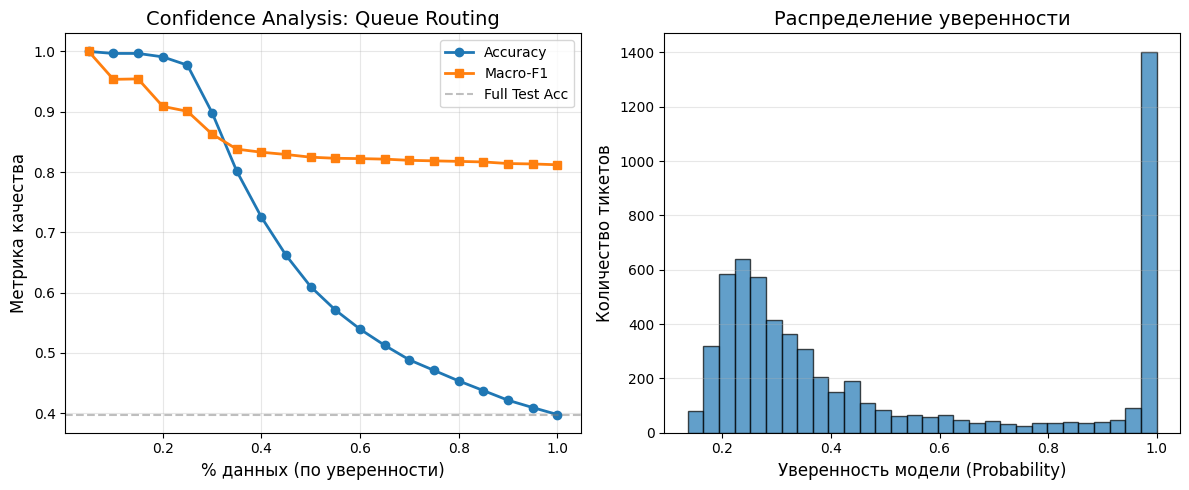


 Вывод: Queue Routing
Охват      | Порог уверенности    | Accuracy   | Macro-F1   | Гипотетическое качество  
--------------------------------------------------------------------------------
50        % | 0.3479               | 0.6095     | 0.8246     | 0.8047                   
70        % | 0.2616               | 0.4883     | 0.8194     | 0.6418                   
80        % | 0.2327               | 0.4534     | 0.8177     | 0.5628                   
90        % | 0.2040               | 0.4214     | 0.8141     | 0.4792                   


In [ ]:
print("\n" + "=" * 60)
print("Анализ Confidence...")
print("=" * 60)

confidence_report = analyze_confidence(
    results['true_queue'],
    results['preds_queue'],
    results['probs_queue'],
    task_name="Queue Routing"
)

Попробуем заменить модель

In [ ]:
MODEL_NAME = "xlm-roberta-base"
BATCH_SIZE = 8
MAX_LENGTH = 128
EPOCHS_FROZEN = 1
EPOCHS_FINETUNE = 2
LR_HEAD = 5e-4
LR_BERT = 1e-5
DROPOUT = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")
print(f"Total epochs: {EPOCHS_FROZEN + EPOCHS_FINETUNE}")


Device: cuda
Model: xlm-roberta-base
Total epochs: 3


In [ ]:
import torch
import gc

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print(f"Свободно памяти: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
    print(f"Зарезервировано: {torch.cuda.memory_reserved(0)/1e9:.2f} GB")

Свободно памяти: 2.27 GB
Зарезервировано: 3.46 GB


In [ ]:
class MultiTaskBERT(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size

        self.dropout = nn.Dropout(dropout)

        self.head_queue = nn.Linear(hidden_size, n_queue)
        self.head_priority = nn.Linear(hidden_size, n_priority)
        self.head_type = nn.Linear(hidden_size, n_type)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)

        return {
            'queue': self.head_queue(cls_embedding),
            'priority': self.head_priority(cls_embedding),
            'type': self.head_type(cls_embedding)
        }

model = MultiTaskBERT(
    MODEL_NAME,
    n_queue=len(le_queue.classes_),
    n_priority=len(le_priority.classes_),
    n_type=len(le_type.classes_),
    dropout=DROPOUT
).to(DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from torch.amp import autocast, GradScaler

class_weights = compute_class_weight('balanced', classes=np.unique(y_train_queue), y=y_train_queue)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion_queue = nn.CrossEntropyLoss(weight=class_weights)
criterion_priority = nn.CrossEntropyLoss()
criterion_type = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {'params': model.head_queue.parameters(), 'lr': LR_HEAD},
    {'params': model.head_priority.parameters(), 'lr': LR_HEAD},
    {'params': model.head_type.parameters(), 'lr': LR_HEAD},
    {'params': model.bert.parameters(), 'lr': LR_BERT},
])

scaler = GradScaler('cuda')

In [ ]:
print("\nЗапуск обучения...")
print("=" * 60)

for epoch in range(1, EPOCHS_FROZEN + 1):
    train_epoch(model, train_loader, optimizer, scaler, epoch, frozen_bert=True)

for epoch in range(EPOCHS_FROZEN + 1, EPOCHS_FROZEN + EPOCHS_FINETUNE + 1):
    train_epoch(model, train_loader, optimizer, scaler, epoch, frozen_bert=False)

print("=" * 60)
print("Обучение завершено. Оценка на validation set...")


Запуск обучения...
Epoch 1 [Frozen]: Loss = 2.8258
Epoch 2 [Fine-tuning]: Loss = 1.1212
Epoch 3 [Fine-tuning]: Loss = 0.6755
Epoch 4 [Fine-tuning]: Loss = 0.5654
Обучение завершено. Оценка на validation set...


In [ ]:
results = evaluate(model, val_loader)

print("\nРезультаты Validation:")
print(f"MacroF1(queue):   {results['macro_f1_queue']:.4f}")
print(f"Acc(queue):       {results['acc_queue']:.4f}")
print(f"Acc(priority):    {results['acc_priority']:.4f}")
print(f"Acc(type):        {results['acc_type']:.4f}")
print(f"Final Score:      {results['final_score']:.4f}")


Результаты Validation:
MacroF1(queue):   0.8230
Acc(queue):       0.4573
Acc(priority):    0.5120
Acc(type):        0.8431
Final Score:      0.7794


Никаких заметных улучшений....


Анализ Confidence...


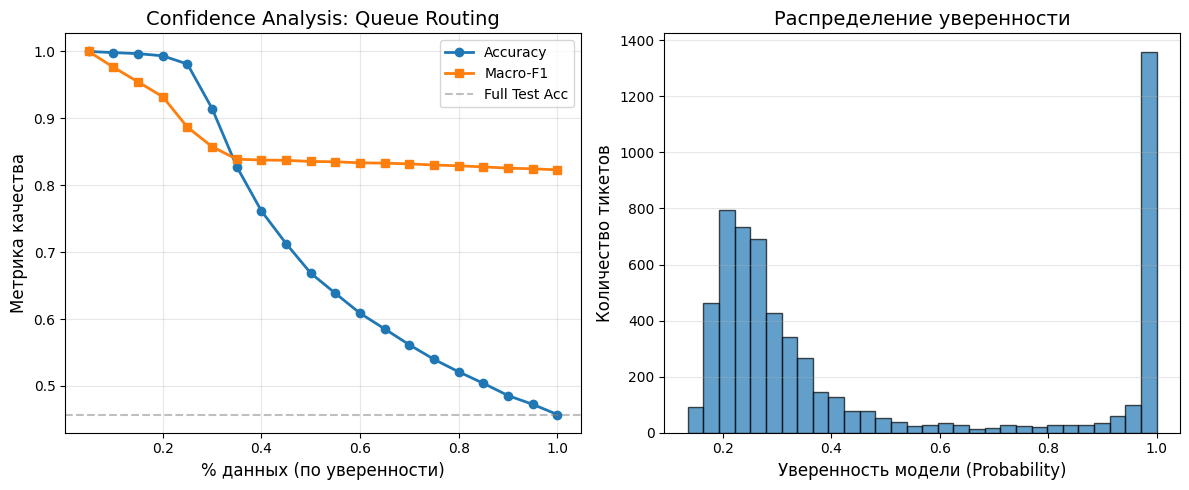


 Вывод: Queue Routing
Охват      | Порог уверенности    | Accuracy   | Macro-F1   | Гипотетическое качество  
--------------------------------------------------------------------------------
50        % | 0.3003               | 0.6687     | 0.8357     | 0.8344                   
70        % | 0.2408               | 0.5614     | 0.8320     | 0.6930                   
80        % | 0.2176               | 0.5211     | 0.8291     | 0.6168                   
90        % | 0.1955               | 0.4856     | 0.8256     | 0.5370                   


In [ ]:
print("\n" + "=" * 60)
print("Анализ Confidence...")
print("=" * 60)

confidence_report = analyze_confidence(
    results['true_queue'],
    results['preds_queue'],
    results['probs_queue'],
    task_name="Queue Routing"
)

Модель хорошо справляется с теми тикетами, в которых она уверена. Когда мы пытаемся автоматически обработать больше тикетов, качество предсказаний начинает снижаться.

Попробуем другой подход: Feature-based BERT (как пробовали на семинаре)

In [ ]:
MODEL_NAME = "bert-base-multilingual-cased"
MAX_LENGTH = 256
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")

Device: cuda
Model: bert-base-multilingual-cased


In [ ]:
le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

y_train_queue = le_queue.fit_transform(df_train['queue'])
y_train_priority = le_priority.fit_transform(df_train['priority'])
y_train_type = le_type.fit_transform(df_train['type'])

y_val_queue = le_queue.transform(df_val['queue'])
y_val_priority = le_priority.transform(df_val['priority'])
y_val_type = le_type.transform(df_val['type'])

print(f"Train samples: {len(df_train)}")
print(f"Val samples: {len(df_val)}")
print(f"Number of queue classes: {len(le_queue.classes_)}")

Train samples: 49412
Val samples: 6176
Number of queue classes: 52


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_backbone = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
bert_backbone.eval()  # Замораживаем модель

@torch.no_grad()
def extract_cls_embeddings(texts, batch_size=BATCH_SIZE, max_length=MAX_LENGTH):

    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            list(batch),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(DEVICE)

        out = bert_backbone(**enc)
        # [CLS] токен - это первая позиция (index 0)
        cls = out.last_hidden_state[:, 0, :].detach().cpu().numpy()
        all_vecs.append(cls)

        # Очистка памяти каждые 10 батчей
        if (i // batch_size) % 10 == 0:
            if DEVICE.type == 'cuda':
                torch.cuda.empty_cache()

    return np.vstack(all_vecs)

print("Извлечение эмбеддингов для train...")
X_train_bert = extract_cls_embeddings(df_train['text'].tolist())

print("Извлечение эмбеддингов для val...")
X_val_bert = extract_cls_embeddings(df_val['text'].tolist())

print(f"Embeddings shape: {X_train_bert.shape}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Извлечение эмбеддингов для train...
Извлечение эмбеддингов для val...
Embeddings shape: (49412, 768)


In [ ]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_queue), y=y_train_queue)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}


clf_queue = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs',
    n_jobs=-1
)

scaler_queue = StandardScaler()
X_train_scaled = scaler_queue.fit_transform(X_train_bert)
X_val_scaled = scaler_queue.transform(X_val_bert)

clf_queue.fit(X_train_scaled, y_train_queue)
queue_pred = clf_queue.predict(X_val_scaled)
queue_proba = clf_queue.predict_proba(X_val_scaled)

clf_priority = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
clf_priority.fit(X_train_scaled, y_train_priority)
priority_pred = clf_priority.predict(X_val_scaled)


clf_type = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
clf_type.fit(X_train_scaled, y_train_type)
type_pred = clf_type.predict(X_val_scaled)


macro_f1_q = f1_score(y_val_queue, queue_pred, average='macro')
acc_q = accuracy_score(y_val_queue, queue_pred)
acc_p = accuracy_score(y_val_priority, priority_pred)
acc_t = accuracy_score(y_val_type, type_pred)

score = 0.70 * macro_f1_q + 0.15 * acc_p + 0.15 * acc_t

print("\nРезультаты Validation (Feature-based BERT):")
print(f"MacroF1(queue):   {macro_f1_q:.4f}")
print(f"Acc(queue):       {acc_q:.4f}")
print(f"Acc(priority):    {acc_p:.4f}")
print(f"Acc(type):        {acc_t:.4f}")
print(f"Final Score:      {score:.4f}")


Результаты Validation (Feature-based BERT):
MacroF1(queue):   0.5124
Acc(queue):       0.3162
Acc(priority):    0.4487
Acc(type):        0.7926
Final Score:      0.5448


Что то совсем плохо стало... У нас 52 класса против 3, как было в семинаре мб поэтому не сработало

Попробуем мб  `LinearSVC` вместо `LogisticRegression`

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import MaxAbsScaler
from sklearn.utils.class_weight import compute_class_weight


class_weights = compute_class_weight('balanced', classes=np.unique(y_train_queue), y=y_train_queue)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

scaler_queue = MaxAbsScaler()
X_train_scaled = scaler_queue.fit_transform(X_train_bert)
X_val_scaled = scaler_queue.transform(X_val_bert)


base_svc = LinearSVC(
    C=3.0,
    class_weight='balanced',
    max_iter=5000,
    dual=False
)

clf_queue = CalibratedClassifierCV(base_svc, method='sigmoid', cv=3)

clf_queue.fit(X_train_scaled, y_train_queue)
queue_pred = clf_queue.predict(X_val_scaled)
queue_proba = clf_queue.predict_proba(X_val_scaled)  # Теперь работает!


clf_priority = LinearSVC(
    C=3.0,
    class_weight='balanced',
    max_iter=5000,
    dual=False
)
clf_priority.fit(X_train_scaled, y_train_priority)
priority_pred = clf_priority.predict(X_val_scaled)

clf_type = LinearSVC(
    C=3.0,
    class_weight='balanced',
    max_iter=5000,
    dual=False
)
clf_type.fit(X_train_scaled, y_train_type)
type_pred = clf_type.predict(X_val_scaled)


macro_f1_q = f1_score(y_val_queue, queue_pred, average='macro')
acc_q = accuracy_score(y_val_queue, queue_pred)
acc_p = accuracy_score(y_val_priority, priority_pred)
acc_t = accuracy_score(y_val_type, type_pred)

score = 0.70 * macro_f1_q + 0.15 * acc_p + 0.15 * acc_t

print("\nРезультаты Validation (Feature-based BERT + LinearSVC):")
print(f"MacroF1(queue):   {macro_f1_q:.4f}")
print(f"Acc(queue):       {acc_q:.4f}")
print(f"Acc(priority):    {acc_p:.4f}")
print(f"Acc(type):        {acc_t:.4f}")
print(f"Final Score:      {score:.4f}")


Результаты Validation (Feature-based BERT + LinearSVC):
MacroF1(queue):   0.5299
Acc(queue):       0.4207
Acc(priority):    0.4607
Acc(type):        0.8151
Final Score:      0.5623


Улучшения минимальны... А столько времени ждали результат

In [ ]:
def confidence_analysis(y_true, y_pred, confidences, task_name="Queue"):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    confidences = np.array(confidences)

    order = np.argsort(-confidences)

    y_true_sorted = y_true[order]
    y_pred_sorted = y_pred[order]
    conf_sorted = confidences[order]

    total = len(y_true)

    coverages = np.linspace(0.1, 1.0, 10)

    rows = []
    acc_values = []
    f1_values = []

    for cov in coverages:

        n = int(total * cov)

        y_true_subset = y_true_sorted[:n]
        y_pred_subset = y_pred_sorted[:n]

        acc = accuracy_score(y_true_subset, y_pred_subset)
        macro_f1 = f1_score(y_true_subset, y_pred_subset, average="macro")

        threshold = conf_sorted[n - 1]

        hypothetical_quality = cov * acc + (1 - cov) * 1.0

        rows.append({
            "coverage": cov,
            "confidence_threshold": threshold,
            "accuracy": acc,
            "macro_f1": macro_f1,
            "hypothetical_system_quality": hypothetical_quality
        })

        acc_values.append(acc)
        f1_values.append(macro_f1)

    results = pd.DataFrame(rows)

    print(f"\nConfidence analysis: {task_name}")
    print("-" * 70)
    print(results.to_string(index=False, float_format="%.4f"))

    # график
    plt.figure(figsize=(7,5))

    plt.plot(coverages, acc_values, marker='o', label="Accuracy")
    plt.plot(coverages, f1_values, marker='o', label="Macro-F1")

    plt.xlabel("Coverage (fraction of automatically processed tickets)")
    plt.ylabel("Metric value")
    plt.title(f"Confidence-based performance: {task_name}")

    plt.legend()
    plt.grid(True)

    plt.show()

    return results



Confidence analysis: Queue Routing
----------------------------------------------------------------------
 coverage  confidence_threshold  accuracy  macro_f1  hypothetical_system_quality
   0.1000                0.4945    0.7212    0.7396                       0.9721
   0.2000                0.4222    0.6170    0.7817                       0.9234
   0.3000                0.3827    0.5756    0.7949                       0.8727
   0.4000                0.3471    0.5441    0.7893                       0.8177
   0.5000                0.3170    0.5058    0.7647                       0.7529
   0.6000                0.2915    0.4864    0.7539                       0.6918
   0.7000                0.2657    0.4626    0.7237                       0.6238
   0.8000                0.2367    0.4423    0.6830                       0.5538
   0.9000                0.1915    0.4332    0.6318                       0.4899
   1.0000                0.0668    0.4207    0.5299                       0.4207


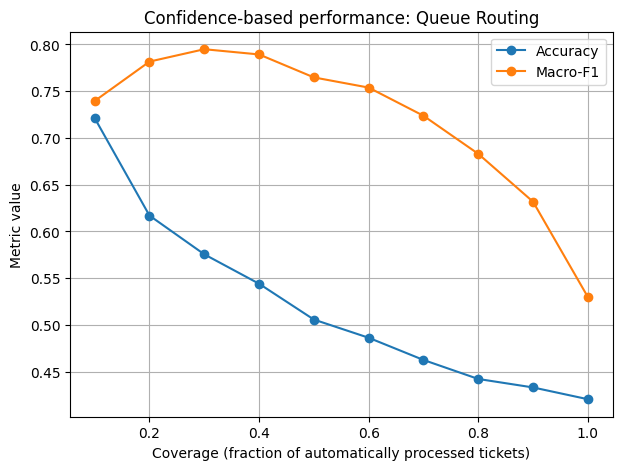

In [ ]:
max_proba_queue = queue_proba.max(axis=1)

confidence_results = confidence_analysis(
    y_val_queue,
    queue_pred,
    max_proba_queue,
    task_name="Queue Routing"
)


Анализ показывает, что модель надёжно классифицирует только часть тикетов, тогда как для остальных примеров её предсказания оказываются менее точными.

Вернемся все же к  fine-tuning, там результаты были получше. Посоветовали мне использовать несколько других моделей + добавим признаков новых, чтобы мб помочь модельке

Начнем с **ModernBert**

In [2]:
# Заново загрузим датасет
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df = dataset["train"].to_pandas()

def load_idx(path):
    with open(path) as f:
        return [int(x.strip()) for x in f]

train_idx = load_idx("train_idx.txt")
val_idx = load_idx("val_idx.txt")
test_idx = load_idx("test_idx.txt")

# Разбивка на сплиты
df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

# Обработка текста
def prepare_text(row):
    subject = str(row['subject']) if pd.notna(row['subject']) else ""
    body = str(row['body']) if pd.notna(row['body']) else ""
    return f"{subject} [SEP] {body}"

for split in [df_train, df_val, df_test]:
    split['text'] = split.apply(prepare_text, axis=1)
    split['type'] = split['type'].fillna("Unknown")

# Новые фичи: длина текста и язык
for split in [df_train, df_val, df_test]:
    split['text_len'] = split['text'].str.len()
    split['word_len'] = split['text'].str.split().map(len)
    split['lang_code'] = LabelEncoder().fit_transform(split['language'].fillna('NA'))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

In [ ]:
queue_le = LabelEncoder()
priority_le = LabelEncoder()
type_le = LabelEncoder()

df_train['queue_id'] = queue_le.fit_transform(df_train['queue'])
df_val['queue_id'] = queue_le.transform(df_val['queue'])
df_train['priority_id'] = priority_le.fit_transform(df_train['priority'])
df_val['priority_id'] = priority_le.transform(df_val['priority'])
df_train['type_id'] = type_le.fit_transform(df_train['type'])
df_val['type_id'] = type_le.transform(df_val['type'])

In [ ]:
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['text'].tolist()
        self.text_len = df['text_len'].values
        self.lang_code = df['lang_code'].values
        self.queue = df['queue_id'].values
        self.priority = df['priority_id'].values
        self.type_ = df['type_id'].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        extra_feats = torch.tensor([self.text_len[idx], self.lang_code[idx]], dtype=torch.float32)
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'extra_feats': extra_feats,
            'queue': torch.tensor(self.queue[idx]),
            'priority': torch.tensor(self.priority[idx]),
            'type': torch.tensor(self.type_[idx])
        }

train_ds = TicketDataset(df_train, tokenizer)
val_ds = TicketDataset(df_val, tokenizer)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)


In [ ]:
class ModernBERTMultiTask(nn.Module):
    def __init__(self, n_queue, n_priority, n_type, extra_features_dim=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size = self.bert.config.hidden_size
        self.extra_features_dim = extra_features_dim

        # Замораживаем все слои кроме последних 2
        for name, param in self.bert.named_parameters():
            if "layer.10" not in name and "layer.11" not in name and "pooler" not in name:
                param.requires_grad = False

        # Heads
        self.queue_head = nn.Linear(hidden_size + extra_features_dim, n_queue)
        self.priority_head = nn.Linear(hidden_size + extra_features_dim, n_priority)
        self.type_head = nn.Linear(hidden_size + extra_features_dim, n_type)

    def forward(self, input_ids, attention_mask, extra_feats):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]  # CLS
        pooled = torch.cat([pooled, extra_feats], dim=1)
        return self.queue_head(pooled), self.priority_head(pooled), self.type_head(pooled)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ModernBERTMultiTask(
    n_queue=len(queue_le.classes_),
    n_priority=len(priority_le.classes_),
    n_type=len(type_le.classes_)
).to(device)

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
criterion = nn.CrossEntropyLoss()



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
num_epochs = 3
best_score = 0.0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        extra_feats = batch['extra_feats'].to(device)
        queue_labels = batch['queue'].to(device)
        priority_labels = batch['priority'].to(device)
        type_labels = batch['type'].to(device)

        optimizer.zero_grad()
        q_logits, p_logits, t_logits = model(input_ids, attention_mask, extra_feats)
        loss = criterion(q_logits, queue_labels) + \
               criterion(p_logits, priority_labels) + \
               criterion(t_logits, type_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f"Epoch {epoch+1}, Batch {i+1}/{len(train_loader)}, Loss: {total_loss/(i+1):.4f}")


    model.eval()
    all_q, all_p, all_t = [], [], []
    all_q_labels, all_p_labels, all_t_labels = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            extra_feats = batch['extra_feats'].to(device)

            q_logits, p_logits, t_logits = model(input_ids, attention_mask, extra_feats)

            all_q.append(q_logits.cpu())
            all_p.append(p_logits.cpu())
            all_t.append(t_logits.cpu())

            all_q_labels.extend(batch['queue'].numpy())
            all_p_labels.extend(batch['priority'].numpy())
            all_t_labels.extend(batch['type'].numpy())

    all_q = torch.cat(all_q).numpy()
    all_p = torch.cat(all_p).numpy()
    all_t = torch.cat(all_t).numpy()

    q_pred = np.argmax(all_q, axis=1)
    p_pred = np.argmax(all_p, axis=1)
    t_pred = np.argmax(all_t, axis=1)

    F1_queue = f1_score(all_q_labels, q_pred, average='macro')
    Acc_priority = accuracy_score(all_p_labels, p_pred)
    Acc_type = accuracy_score(all_t_labels, t_pred)
    combined_score = 0.7*F1_queue + 0.2*Acc_priority + 0.1*Acc_type

    print(f"Epoch {epoch+1} Validation -> F1_queue: {F1_queue:.4f}, "
          f"Acc_priority: {Acc_priority:.4f}, Acc_type: {Acc_type:.4f}, "
          f"Combined score: {combined_score:.4f}")

    if combined_score > best_score:
        best_score = combined_score
        torch.save(model.state_dict(), "best_modernbert_multitask.pth")
        print("Saved best model!")



Epoch 1, Batch 100/3089, Loss: 26.9133
Epoch 1, Batch 200/3089, Loss: 24.7926
Epoch 1, Batch 300/3089, Loss: 22.6614
Epoch 1, Batch 400/3089, Loss: 20.9183
Epoch 1, Batch 500/3089, Loss: 19.2438
Epoch 1, Batch 600/3089, Loss: 17.9394
Epoch 1, Batch 700/3089, Loss: 16.6925
Epoch 1, Batch 800/3089, Loss: 15.6199
Epoch 1, Batch 900/3089, Loss: 14.6562
Epoch 1, Batch 1000/3089, Loss: 13.8488
Epoch 1, Batch 1100/3089, Loss: 13.1173
Epoch 1, Batch 1200/3089, Loss: 12.5070
Epoch 1, Batch 1300/3089, Loss: 11.9445
Epoch 1, Batch 1400/3089, Loss: 11.4692
Epoch 1, Batch 1500/3089, Loss: 11.0336
Epoch 1, Batch 1600/3089, Loss: 10.6430
Epoch 1, Batch 1700/3089, Loss: 10.3016
Epoch 1, Batch 1800/3089, Loss: 9.9978
Epoch 1, Batch 1900/3089, Loss: 9.7120
Epoch 1, Batch 2000/3089, Loss: 9.4482
Epoch 1, Batch 2100/3089, Loss: 9.2098
Epoch 1, Batch 2200/3089, Loss: 8.9883
Epoch 1, Batch 2300/3089, Loss: 8.7914
Epoch 1, Batch 2400/3089, Loss: 8.6017
Epoch 1, Batch 2500/3089, Loss: 8.4283
Epoch 1, Batch 26

In [11]:
def confidence_analysis(true_labels, preds, probs, task_name="Task"):
    import matplotlib.pyplot as plt
    sorted_idx = np.argsort(-probs)
    true_sorted = np.array(true_labels)[sorted_idx]
    preds_sorted = np.array(preds)[sorted_idx]
    probs_sorted = probs[sorted_idx]
    total_samples = len(true_labels)
    coverages = [0.5, 0.7, 0.8, 0.9, 1.0]

    print(f"\nConfidence Analysis: {task_name}")
    print("-"*80)
    print(f"{'Coverage':<10} | {'Conf Threshold':<15} | {'Accuracy':<10} | {'Macro-F1':<10}")
    print("-"*80)
    for cov in coverages:
        n = int(total_samples * cov)
        acc = accuracy_score(true_sorted[:n], preds_sorted[:n])
        f1 = f1_score(true_sorted[:n], preds_sorted[:n], average='macro')
        thresh = probs_sorted[n-1]
        print(f"{cov:<10.2f} | {thresh:<15.4f} | {acc:<10.4f} | {f1:<10.4f}")
    print("-"*80)


    plt.figure(figsize=(8,4))
    plt.hist(probs, bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel("Confidence")
    plt.ylabel("Number of samples")
    plt.title(f"Confidence distribution: {task_name}")
    plt.show()


Confidence Analysis: Queue Routing
--------------------------------------------------------------------------------
Coverage   | Conf Threshold  | Accuracy   | Macro-F1  
--------------------------------------------------------------------------------
0.50       | 0.3952          | 0.6454     | 0.7586    
0.70       | 0.3117          | 0.5647     | 0.7229    
0.80       | 0.2758          | 0.5338     | 0.7050    
0.90       | 0.2446          | 0.5056     | 0.6904    
1.00       | 0.0839          | 0.4809     | 0.6451    
--------------------------------------------------------------------------------


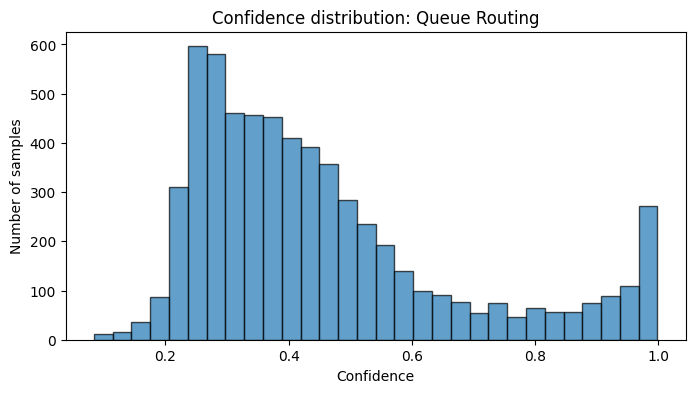

In [ ]:
model.eval()
all_q_logits = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        extra_feats = batch['extra_feats'].to(device)
        q_logits, _, _ = model(input_ids, attention_mask, extra_feats)
        all_q_logits.append(q_logits.cpu())

all_q_logits = torch.cat(all_q_logits).numpy()
q_pred = np.argmax(all_q_logits, axis=1)
q_proba = torch.softmax(torch.tensor(all_q_logits), dim=1).numpy()
max_proba_q = q_proba.max(axis=1)

confidence_analysis(all_q_labels, q_pred, max_proba_q, task_name="Queue Routing")


Потенциал у модели был, добавим большее количество эпох; добавим Class weights для queue; Class weights для queue

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ModernBERTMultiTask(
    n_queue=len(queue_le.classes_),
    n_priority=len(priority_le.classes_),
    n_type=len(type_le.classes_)
).to(device)


queue_counts = np.bincount(df_train['queue_id'])
queue_weights = 1.0 / (queue_counts + 1e-6)
queue_weights = queue_weights / queue_weights.sum() * len(queue_counts)
queue_weights = torch.tensor(queue_weights, dtype=torch.float32).to(device)

criterion_queue = nn.CrossEntropyLoss(weight=queue_weights)
criterion_priority = nn.CrossEntropyLoss()
criterion_type = nn.CrossEntropyLoss()


param_groups = [
    {"params": [p for n, p in model.bert.named_parameters() if p.requires_grad], "lr": 2e-5},
    {"params": [p for n, p in model.named_parameters() if p.requires_grad and "bert" not in n], "lr": 5e-5}
]
optimizer = torch.optim.AdamW(param_groups)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
num_epochs = 5
best_score = 0.0

for epoch in range(1, num_epochs+1):
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader, 1):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        extra_feats = batch['extra_feats'].to(device)
        q_labels = batch['queue'].to(device)
        p_labels = batch['priority'].to(device)
        t_labels = batch['type'].to(device)

        optimizer.zero_grad()
        q_logits, p_logits, t_logits = model(input_ids, attention_mask, extra_feats)
        loss = criterion_queue(q_logits, q_labels) + \
               criterion_priority(p_logits, p_labels) + \
               criterion_type(t_logits, t_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if i % 100 == 0:
            print(f"Epoch {epoch}, Batch {i}/{len(train_loader)}, Loss: {total_loss/100:.4f}")
            total_loss = 0


    model.eval()
    all_q_logits, all_p_logits, all_t_logits = [], [], []
    all_q_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            extra_feats = batch['extra_feats'].to(device)
            q_logits, p_logits, t_logits = model(input_ids, attention_mask, extra_feats)
            all_q_logits.append(q_logits.cpu())
            all_p_logits.append(p_logits.cpu())
            all_t_logits.append(t_logits.cpu())
            all_q_labels.extend(batch['queue'].numpy())

    all_q_logits = torch.cat(all_q_logits).numpy()
    q_pred = np.argmax(all_q_logits, axis=1)
    q_f1 = f1_score(all_q_labels, q_pred, average='macro')
    p_acc = accuracy_score(df_val['priority_id'], np.argmax(np.concatenate(all_p_logits), axis=1))
    t_acc = accuracy_score(df_val['type_id'], np.argmax(np.concatenate(all_t_logits), axis=1))
    combined_score = 0.7 * q_f1 + 0.2 * p_acc + 0.1 * t_acc

    print(f"Epoch {epoch} Validation -> F1_queue: {q_f1:.4f}, Acc_priority: {p_acc:.4f}, Acc_type: {t_acc:.4f}, Combined score: {combined_score:.4f}")

    # Save best model
    if combined_score > best_score:
        torch.save(model.state_dict(), "best_model.pth")
        best_score = combined_score
        print("Saved best model!")

Epoch 1, Batch 100/3089, Loss: 31.9094
Epoch 1, Batch 200/3089, Loss: 21.3828
Epoch 1, Batch 300/3089, Loss: 15.8343
Epoch 1, Batch 400/3089, Loss: 12.7079
Epoch 1, Batch 500/3089, Loss: 10.9496
Epoch 1, Batch 600/3089, Loss: 9.1985
Epoch 1, Batch 700/3089, Loss: 8.0392
Epoch 1, Batch 800/3089, Loss: 7.3399
Epoch 1, Batch 900/3089, Loss: 6.7224
Epoch 1, Batch 1000/3089, Loss: 6.3421
Epoch 1, Batch 1100/3089, Loss: 6.5160
Epoch 1, Batch 1200/3089, Loss: 6.1797
Epoch 1, Batch 1300/3089, Loss: 5.9350
Epoch 1, Batch 1400/3089, Loss: 5.4626
Epoch 1, Batch 1500/3089, Loss: 5.5500
Epoch 1, Batch 1600/3089, Loss: 5.4137
Epoch 1, Batch 1700/3089, Loss: 5.3029
Epoch 1, Batch 1800/3089, Loss: 5.0815
Epoch 1, Batch 1900/3089, Loss: 5.0079
Epoch 1, Batch 2000/3089, Loss: 4.7752
Epoch 1, Batch 2100/3089, Loss: 4.7500
Epoch 1, Batch 2200/3089, Loss: 4.5336
Epoch 1, Batch 2300/3089, Loss: 4.3447
Epoch 1, Batch 2400/3089, Loss: 4.2769
Epoch 1, Batch 2500/3089, Loss: 4.1561
Epoch 1, Batch 2600/3089, Los

Немного лучше, но мы явно уперлись в потолок


Confidence Analysis: Queue Routing
--------------------------------------------------------------------------------
Coverage   | Conf Threshold  | Accuracy   | Macro-F1  
--------------------------------------------------------------------------------
0.50       | 0.2858          | 0.6619     | 0.8339    
0.70       | 0.2332          | 0.5327     | 0.8243    
0.80       | 0.2105          | 0.4899     | 0.8198    
0.90       | 0.1855          | 0.4541     | 0.8165    
1.00       | 0.1226          | 0.4260     | 0.8147    
--------------------------------------------------------------------------------


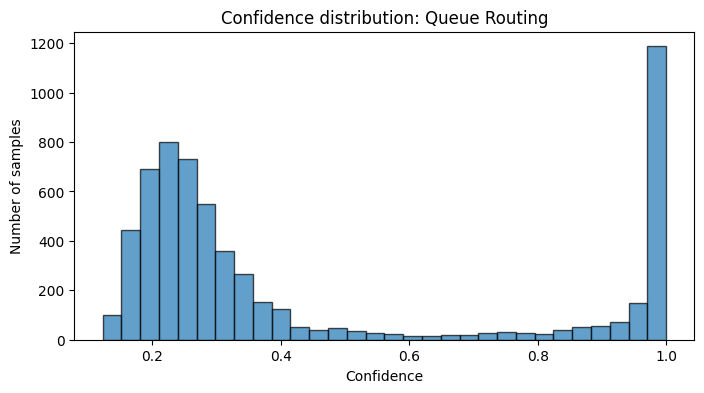

In [ ]:
model.eval()
all_q_logits = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        extra_feats = batch['extra_feats'].to(device)
        q_logits, _, _ = model(input_ids, attention_mask, extra_feats)
        all_q_logits.append(q_logits.cpu())

all_q_logits = torch.cat(all_q_logits).numpy()
q_pred = np.argmax(all_q_logits, axis=1)
q_proba = torch.softmax(torch.tensor(all_q_logits), dim=1).numpy()
max_proba_q = q_proba.max(axis=1)

confidence_analysis(all_q_labels, q_pred, max_proba_q, task_name="Queue Routing")


по метрике `confidence` тоже получше история

## Лучший Transformer fine-tuning на multitask

Попробуем еще немного улучшить, добавим новые фичи + параметры поменяем немного

In [3]:
for d in [df_train, df_val, df_test]:
    d['n_words'] = d['text'].str.split().str.len()
    d['n_sentences'] = d['text'].str.count(r'\.') + 1

In [4]:
queue_le = LabelEncoder()
priority_le = LabelEncoder()
type_le = LabelEncoder()

df_train['queue_id'] = queue_le.fit_transform(df_train['queue'])
df_val['queue_id'] = queue_le.transform(df_val['queue'])
df_train['priority_id'] = priority_le.fit_transform(df_train['priority'])
df_val['priority_id'] = priority_le.transform(df_val['priority'])
df_train['type_id'] = type_le.fit_transform(df_train['type'])
df_val['type_id'] = type_le.transform(df_val['type'])


In [5]:
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['text'].tolist()
        self.extra_feats = df[['text_len','lang_code','n_words','n_sentences']].values
        self.queue = df['queue_id'].values
        self.priority = df['priority_id'].values
        self.type_ = df['type_id'].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        extra_feats = torch.tensor(self.extra_feats[idx], dtype=torch.float32)
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'extra_feats': extra_feats,
            'queue': torch.tensor(self.queue[idx]),
            'priority': torch.tensor(self.priority[idx]),
            'type': torch.tensor(self.type_[idx])
        }

train_ds = TicketDataset(df_train, tokenizer)
val_ds = TicketDataset(df_val, tokenizer)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
class ModernBERTMultiTask(nn.Module):
    def __init__(self, n_queue, n_priority, n_type, extra_features_dim=4):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size = self.bert.config.hidden_size

        # Замораживаем все слои кроме последних 4 блоков
        for name, param in self.bert.named_parameters():
            if not any(f"layer.{i}" in name for i in [8,9,10,11]) and "pooler" not in name:
                param.requires_grad = False

        # Heads
        self.queue_head = nn.Linear(hidden_size + extra_features_dim, n_queue)
        self.priority_head = nn.Linear(hidden_size + extra_features_dim, n_priority)
        self.type_head = nn.Linear(hidden_size + extra_features_dim, n_type)

    def forward(self, input_ids, attention_mask, extra_feats):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]  # CLS
        pooled = torch.cat([pooled, extra_feats], dim=1)
        return self.queue_head(pooled), self.priority_head(pooled), self.type_head(pooled)


In [7]:
queue_weight = 0.7
priority_weight = 0.15
type_weight = 0.15


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ModernBERTMultiTask(
    n_queue=len(queue_le.classes_),
    n_priority=len(priority_le.classes_),
    n_type=len(type_le.classes_),
    extra_features_dim=4
).to(device)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)

criterion = nn.CrossEntropyLoss()

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
best_combined = 0.0
for epoch in range(4):
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        extra_feats = batch['extra_feats'].to(device)
        queue_labels = batch['queue'].to(device)
        priority_labels = batch['priority'].to(device)
        type_labels = batch['type'].to(device)

        optimizer.zero_grad()
        q_logits, p_logits, t_logits = model(input_ids, attention_mask, extra_feats)

        # Weighted multitask loss
        loss = queue_weight * criterion(q_logits, queue_labels) + \
               priority_weight * criterion(p_logits, priority_labels) + \
               type_weight * criterion(t_logits, type_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f"Epoch {epoch+1}, Batch {i+1}/{len(train_loader)}, Loss: {total_loss/100:.4f}")
            total_loss = 0

    model.eval()
    all_queue_pred, all_queue_true = [], []
    all_priority_pred, all_priority_true = [], []
    all_type_pred, all_type_true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            extra_feats = batch['extra_feats'].to(device)
            q_logits, p_logits, t_logits = model(input_ids, attention_mask, extra_feats)

            all_queue_pred.extend(q_logits.argmax(dim=1).cpu().numpy())
            all_queue_true.extend(batch['queue'].numpy())
            all_priority_pred.extend(p_logits.argmax(dim=1).cpu().numpy())
            all_priority_true.extend(batch['priority'].numpy())
            all_type_pred.extend(t_logits.argmax(dim=1).cpu().numpy())
            all_type_true.extend(batch['type'].numpy())

    f1_queue = f1_score(all_queue_true, all_queue_pred, average='macro')
    acc_priority = np.mean(np.array(all_priority_pred) == np.array(all_priority_true))
    acc_type = np.mean(np.array(all_type_pred) == np.array(all_type_true))
    combined_score = 0.7 * f1_queue + 0.15 * acc_priority + 0.15 * acc_type

    print(f"Epoch {epoch+1} Validation -> F1_queue: {f1_queue:.4f}, Acc_priority: {acc_priority:.4f}, Acc_type: {acc_type:.4f}, Combined score: {combined_score:.4f}")

    # Scheduler step
    scheduler.step(combined_score)

    if combined_score > best_combined:
        best_combined = combined_score
        torch.save(model.state_dict(), "best_model.pt")
        print("Saved best model!")


Epoch 1, Batch 100/3089, Loss: 15.3440
Epoch 1, Batch 200/3089, Loss: 12.7718
Epoch 1, Batch 300/3089, Loss: 10.5584
Epoch 1, Batch 400/3089, Loss: 8.8926
Epoch 1, Batch 500/3089, Loss: 7.4994
Epoch 1, Batch 600/3089, Loss: 6.2077
Epoch 1, Batch 700/3089, Loss: 5.0018
Epoch 1, Batch 800/3089, Loss: 4.5549
Epoch 1, Batch 900/3089, Loss: 3.8735
Epoch 1, Batch 1000/3089, Loss: 3.4966
Epoch 1, Batch 1100/3089, Loss: 3.2300
Epoch 1, Batch 1200/3089, Loss: 2.9917
Epoch 1, Batch 1300/3089, Loss: 2.7799
Epoch 1, Batch 1400/3089, Loss: 2.6953
Epoch 1, Batch 1500/3089, Loss: 2.6449
Epoch 1, Batch 1600/3089, Loss: 2.5667
Epoch 1, Batch 1700/3089, Loss: 2.3855
Epoch 1, Batch 1800/3089, Loss: 2.3157
Epoch 1, Batch 1900/3089, Loss: 2.1842
Epoch 1, Batch 2000/3089, Loss: 2.1661
Epoch 1, Batch 2100/3089, Loss: 2.1400
Epoch 1, Batch 2200/3089, Loss: 1.9940
Epoch 1, Batch 2300/3089, Loss: 2.0016
Epoch 1, Batch 2400/3089, Loss: 1.9702
Epoch 1, Batch 2500/3089, Loss: 1.8351
Epoch 1, Batch 2600/3089, Loss:

Сделаем предказание на тесте

In [13]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()


ModernBERTMultiTask(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [15]:
# label encoding для test

df_test['queue_id'] = queue_le.transform(df_test['queue'])
df_test['priority_id'] = priority_le.transform(df_test['priority'])
df_test['type_id'] = type_le.transform(df_test['type'])

test_ds = TicketDataset(df_test, tokenizer)
test_loader = DataLoader(test_ds, batch_size=32)


In [16]:
all_queue_pred, all_queue_true = [], []
all_priority_pred, all_priority_true = [], []
all_type_pred, all_type_true = [], []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        extra_feats = batch['extra_feats'].to(device)

        q_logits, p_logits, t_logits = model(input_ids, attention_mask, extra_feats)

        all_queue_pred.extend(q_logits.argmax(dim=1).cpu().numpy())
        all_queue_true.extend(batch['queue'].numpy())

        all_priority_pred.extend(p_logits.argmax(dim=1).cpu().numpy())
        all_priority_true.extend(batch['priority'].numpy())

        all_type_pred.extend(t_logits.argmax(dim=1).cpu().numpy())
        all_type_true.extend(batch['type'].numpy())


In [17]:
f1_queue = f1_score(all_queue_true, all_queue_pred, average="macro")

acc_priority = np.mean(
    np.array(all_priority_pred) == np.array(all_priority_true)
)

acc_type = np.mean(
    np.array(all_type_pred) == np.array(all_type_true)
)

combined_score = 0.7 * f1_queue + 0.15 * acc_priority + 0.15 * acc_type

print("\n Финальный результат")
print("-------------------")
print(f"F1_queue      : {f1_queue:.4f}")
print(f"Acc_priority  : {acc_priority:.4f}")
print(f"Acc_type      : {acc_type:.4f}")
print(f"Combined score: {combined_score:.4f}")



 Финальный результат
-------------------
F1_queue      : 0.8337
Acc_priority  : 0.5370
Acc_type      : 0.8405
Combined score: 0.7902


In [18]:
all_queue_logits = []
all_queue_true = []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        extra_feats = batch['extra_feats'].to(device)

        q_logits, p_logits, t_logits = model(input_ids, attention_mask, extra_feats)

        all_queue_logits.append(q_logits.cpu())
        all_queue_true.extend(batch['queue'].numpy())

all_queue_logits = torch.cat(all_queue_logits).numpy()


In [20]:
probs = torch.softmax(torch.tensor(all_queue_logits), dim=1).numpy()
max_probs = probs.max(axis=1)
preds = np.argmax(probs, axis=1)

In [22]:
sorted_idx = np.argsort(-max_probs)

true_sorted = np.array(all_queue_true)[sorted_idx]
preds_sorted = preds[sorted_idx]
probs_sorted = max_probs[sorted_idx]

total_samples = len(all_queue_true)

coverages = [0.5, 0.7, 0.8, 0.9, 1.0]

print("\n Анализ метрики confidence")
print("-"*70)
print(f"{'Coverage':<10} | {'Conf Threshold':<15} | {'Accuracy':<10} | {'Macro-F1':<10}")
print("-"*70)

for cov in coverages:

    n = int(total_samples * cov)

    acc = accuracy_score(true_sorted[:n], preds_sorted[:n])
    f1 = f1_score(true_sorted[:n], preds_sorted[:n], average='macro')
    thresh = probs_sorted[n-1]

    print(f"{cov:<10.2f} | {thresh:<15.4f} | {acc:<10.4f} | {f1:<10.4f}")



 Анализ метрики confidence
----------------------------------------------------------------------
Coverage   | Conf Threshold  | Accuracy   | Macro-F1  
----------------------------------------------------------------------
0.50       | 0.5096          | 0.7782     | 0.8792    
0.70       | 0.4096          | 0.6718     | 0.8584    
0.80       | 0.3665          | 0.6260     | 0.8509    
0.90       | 0.3237          | 0.5899     | 0.8449    
1.00       | 0.1797          | 0.5546     | 0.8337    


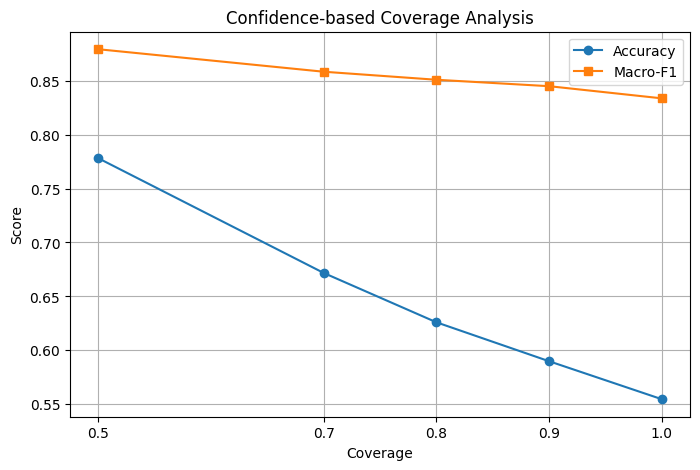

In [23]:
conf_thresholds = []
accuracies = []
f1_scores = []

for cov in coverages:
    n = int(total_samples * cov)
    acc = accuracy_score(true_sorted[:n], preds_sorted[:n])
    f1 = f1_score(true_sorted[:n], preds_sorted[:n], average='macro')
    thresh = probs_sorted[n-1]

    conf_thresholds.append(thresh)
    accuracies.append(acc)
    f1_scores.append(f1)

# График
plt.figure(figsize=(8,5))
plt.plot(coverages, accuracies, marker='o', label='Accuracy')
plt.plot(coverages, f1_scores, marker='s', label='Macro-F1')
plt.xlabel('Coverage')
plt.ylabel('Score')
plt.title('Confidence-based Coverage Analysis')
plt.xticks(coverages)
plt.grid(True)
plt.legend()
plt.show()

Результаты confidence-анализа показывают, если автоматически обрабатывать около 80% тикетов с наибольшей уверенностью, качество классификации (Macro-F1 ≈ 0.85) будет выше, чем при использовании всех предсказаний (Macro-F1 ≈ 0.83), а оставшиеся тикеты можно передавать на ручную обработку

 **Вывод**

Смотрели модели `bert-base-multilingual-cased` и `xlm-roberta-base`, потому что наши тексты на двух языках — английском и немецком. Эти модели умеют понимать несколько языков одновременно. BERT взяли для стабильной базовой работы, а XLM-RoBERTa попробовали для эксперимента, так как она часто лучше работает с мультиязычными текстами. В итоге остановились на `bert-base-multilingual-cased` с дополнительными простыми фичами и размороженными последними слоями, что дало лучший результат при имеющихся ресурсах

Ради интереса ещё пробовали BERT без дообучения — просто вытаскивали признаки из текста и обучали на них LinearSVC. Результат оказался низким (Final Score ≈ 0.56), поэтому этот подход не подошёл для нашей задачи.


## Улучшение Tf-idf + линейная модель

Так как проявил себя tf-idf лучше на этом датасете, попробуем увеличить итоговый скор

Начнем с простого, поменяем немного параметры модели

In [112]:
vectorizer = TfidfVectorizer(
    max_features=250000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2,5),
    min_df=3,
    max_features=80000
)

In [149]:
X_train_word = vectorizer.fit_transform(df_train["text"])
X_val_word = vectorizer.transform(df_val["text"])

X_train_char = char_vectorizer.fit_transform(df_train["text"])
X_val_char = char_vectorizer.transform(df_val["text"])

Добавим фичу с языком текста в виде one-hot кодирования, чтобы модель знала, на каком языке написан тикет

In [150]:
lang_encoder = OneHotEncoder()

lang_train = lang_encoder.fit_transform(df_train[["language"]])
lang_val = lang_encoder.transform(df_val[["language"]])

X_train = hstack([X_train_word, X_train_char, lang_train])
X_val = hstack([X_val_word, X_val_char, lang_val])

In [117]:
model = LinearSVC(
    C=3,
    class_weight="balanced",
    dual=False,
    max_iter=5000
)

model_priority = LinearSVC(
    C=3,
    class_weight="balanced",
    dual=False,
    max_iter=5000
)

model_type = LinearSVC(
    C=3,
    class_weight="balanced",
    dual=False,
    max_iter=5000
)



In [151]:
model.fit(X_train, df_train["queue"])
model_priority.fit(X_train, df_train["priority"])
model_type.fit(X_train, df_train["type"])

LinearSVC(C=3, class_weight='balanced', dual=False, max_iter=5000)

In [152]:
queue_pred = model.predict(X_val)
priority_pred = model_priority.predict(X_val)
type_pred = model_type.predict(X_val)

In [153]:
results = evaluate_ticket_routing(
    df_val["queue"],
    queue_pred,
    df_val["priority"],
    priority_pred,
    df_val["type"],
    type_pred
)

MacroF1(queue):   0.9095
Acc(queue):       0.6907
Acc(priority):    0.7280
Acc(type):        0.8943
Final score:      0.8800


Прогоним на тесте

In [154]:
lang_test = lang_encoder.fit_transform(df_test[["language"]])
X_test_word = vectorizer.transform(df_test["text"])
X_test_char = char_vectorizer.transform(df_test["text"])
X_test = hstack([X_test_word, X_test_char, lang_test])


queue_pred_test = model.predict(X_test)
priority_pred_test = model_priority.predict(X_test)
type_pred_test = model_type.predict(X_test)

test_results = evaluate_ticket_routing(
    df_test["queue"], queue_pred_test,
    df_test["priority"], priority_pred_test,
    df_test["type"], type_pred_test
)

MacroF1(queue):   0.9106
Acc(queue):       0.6913
Acc(priority):    0.7240
Acc(type):        0.9004
Final score:      0.8811


In [155]:
queue_probs = model.decision_function(X_val)
max_probs = np.max(queue_probs, axis=1)

sorted_idx = np.argsort(-max_probs)
true_sorted = np.array(df_val["queue"])[sorted_idx]
preds_sorted = queue_pred[sorted_idx]
probs_sorted = max_probs[sorted_idx]

coverages = [0.5, 0.7, 0.8, 0.9, 1.0]
results_list = []

for cov in coverages:
    n = int(len(true_sorted) * cov)
    acc = accuracy_score(true_sorted[:n], preds_sorted[:n])
    f1 = f1_score(true_sorted[:n], preds_sorted[:n], average='macro')
    thresh = probs_sorted[n-1]
    results_list.append([cov, thresh, acc, f1])


df_confidence = pd.DataFrame(results_list, columns=["Coverage", "Conf_Threshold", "Accuracy", "Macro_F1"])
print("\nConfidence Analysis:")
df_confidence


Confidence Analysis:


,Coverage,Conf_Threshold,Accuracy,Macro_F1
0,0.5,-0.159377,0.915479,0.966193
1,0.7,-0.386977,0.821189,0.940976
2,0.8,-0.480493,0.778340,0.930854
3,0.9,-0.578459,0.736596,0.921429
4,1.0,-0.914080,0.690738,0.909535


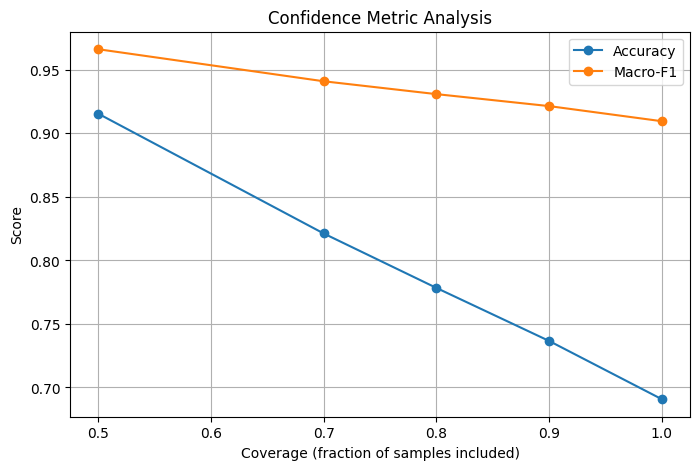

In [156]:
plt.figure(figsize=(8,5))
plt.plot(df_confidence["Coverage"], df_confidence["Accuracy"], marker='o', label="Accuracy")
plt.plot(df_confidence["Coverage"], df_confidence["Macro_F1"], marker='o', label="Macro-F1")
plt.xlabel("Coverage (fraction of samples included)")
plt.ylabel("Score")
plt.title("Confidence Metric Analysis")
plt.grid(True)
plt.legend()
plt.show()

Попробуем добавить фичу text length

In [124]:
df_train["text_len"] = df_train["text"].str.len()
df_val["text_len"] = df_val["text"].str.len()

In [127]:
scaler = StandardScaler()

len_train = scaler.fit_transform(df_train[["text_len"]])
len_val = scaler.transform(df_val[["text_len"]])

len_train = csr_matrix(len_train)
len_val = csr_matrix(len_val)

In [131]:
X_train = hstack([
    X_train_word,
    X_train_char,
    lang_train,
    len_train
])

X_val = hstack([
    X_val_word,
    X_val_char,
    lang_val,
    len_val
])

In [132]:
model.fit(X_train, df_train["queue"])
model_priority.fit(X_train, df_train["priority"])
model_type.fit(X_train, df_train["type"])

LinearSVC(C=3, class_weight='balanced', dual=False, max_iter=5000)

In [133]:
queue_pred = model.predict(X_val)
priority_pred = model_priority.predict(X_val)
type_pred = model_type.predict(X_val)

In [134]:
results = evaluate_ticket_routing(
    df_val["queue"],
    queue_pred,
    df_val["priority"],
    priority_pred,
    df_val["type"],
    type_pred
)

MacroF1(queue):   0.9097
Acc(queue):       0.6911
Acc(priority):    0.7290
Acc(type):        0.8943
Final score:      0.8802


Прогоним на тесте

In [135]:
df_test["text_len"] = df_test["text"].str.len()
len_test = scaler.fit_transform(df_test[["text_len"]])
len_test = csr_matrix(len_test)

In [136]:
X_test = hstack([
    X_test_word,
    X_test_char,
    lang_test,
    len_test
])

In [138]:
queue_pred_test = model.predict(X_test)
priority_pred_test = model_priority.predict(X_test)
type_pred_test = model_type.predict(X_test)

test_results = evaluate_ticket_routing(
    df_test["queue"], queue_pred_test,
    df_test["priority"], priority_pred_test,
    df_test["type"], type_pred_test)

MacroF1(queue):   0.9112
Acc(queue):       0.6918
Acc(priority):    0.7246
Acc(type):        0.9004
Final score:      0.8816


In [142]:
queue_probs = model.decision_function(X_val)
max_probs = np.max(queue_probs, axis=1)

sorted_idx = np.argsort(-max_probs)
true_sorted = np.array(df_val["queue"])[sorted_idx]
preds_sorted = queue_pred[sorted_idx]
probs_sorted = max_probs[sorted_idx]

coverages = [0.5, 0.7, 0.8, 0.9, 1.0]
results_list = []

for cov in coverages:
    n = int(len(true_sorted) * cov)
    acc = accuracy_score(true_sorted[:n], preds_sorted[:n])
    f1 = f1_score(true_sorted[:n], preds_sorted[:n], average='macro')
    thresh = probs_sorted[n-1]
    results_list.append([cov, thresh, acc, f1])


df_confidence = pd.DataFrame(results_list, columns=["Coverage", "Conf_Threshold", "Accuracy", "Macro_F1"])
print("\nConfidence Analysis:")
df_confidence


Confidence Analysis:


,Coverage,Conf_Threshold,Accuracy,Macro_F1
0,0.5,-0.158485,0.915479,0.966125
1,0.7,-0.387672,0.820726,0.940672
2,0.8,-0.481066,0.778138,0.930980
3,0.9,-0.578076,0.736416,0.921459
4,1.0,-0.912491,0.691062,0.909656


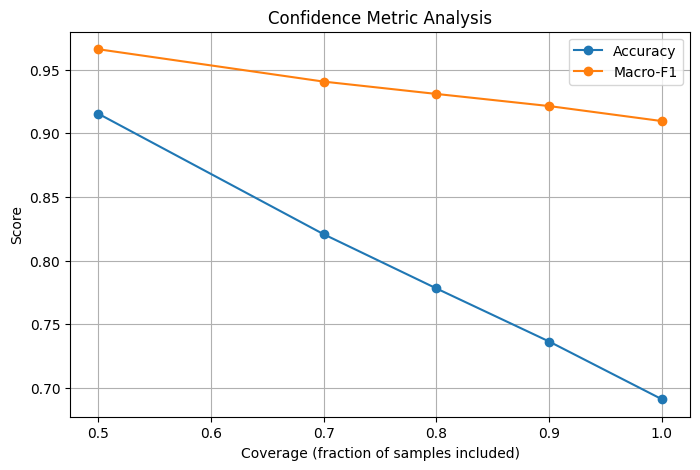

In [141]:
plt.figure(figsize=(8,5))
plt.plot(df_confidence["Coverage"], df_confidence["Accuracy"], marker='o', label="Accuracy")
plt.plot(df_confidence["Coverage"], df_confidence["Macro_F1"], marker='o', label="Macro-F1")
plt.xlabel("Coverage (fraction of samples included)")
plt.ylabel("Score")
plt.title("Confidence Metric Analysis")
plt.grid(True)
plt.legend()
plt.show()

Если автоматически обрабатывать только 70% самых уверенных тикетов, а остальные 30% передавать на ручную проверку, то общее качество системы составит:
0.7 * 0.8207 + 0.3 * 1.0 = 0.8745 или 87.45%

Это выше, чем качество полностью автоматической системы (69.11%), при этом вы экономите 70% времени операторов

Порог 70% — хороший баланс между качеством и автоматизацией. Если нужно ещё выше качество — можно снизить охват до 50%, но тогда экономия времени будет меньше.


## Итог

**Главный результат**: Лучшим решением для задачи маршрутизации тикетов стала классическая модель на основе TF-IDF и линейного классификатора LinearSVC с дополнительными признаками. Финальный скор на тестовой выборке составил 0.8816

Трансформеры показали результат ниже. Для правильного определения запроса важны не глубокие смысловые связи, а точные совпадения ключевых терминов. Модель TF-IDF фиксирует такие совпадения напрямую, тогда как трансформеры ищут более глубокие связи, которые в данном случае не являются решающими

В датасете 52 класса очереди с сильным дисбалансом. Линейные модели с балансировкой весов эффективно справляются с таким дисбалансом, тогда как трансформеры склонны игнорировать редкие классы без специальных техник регуляризации

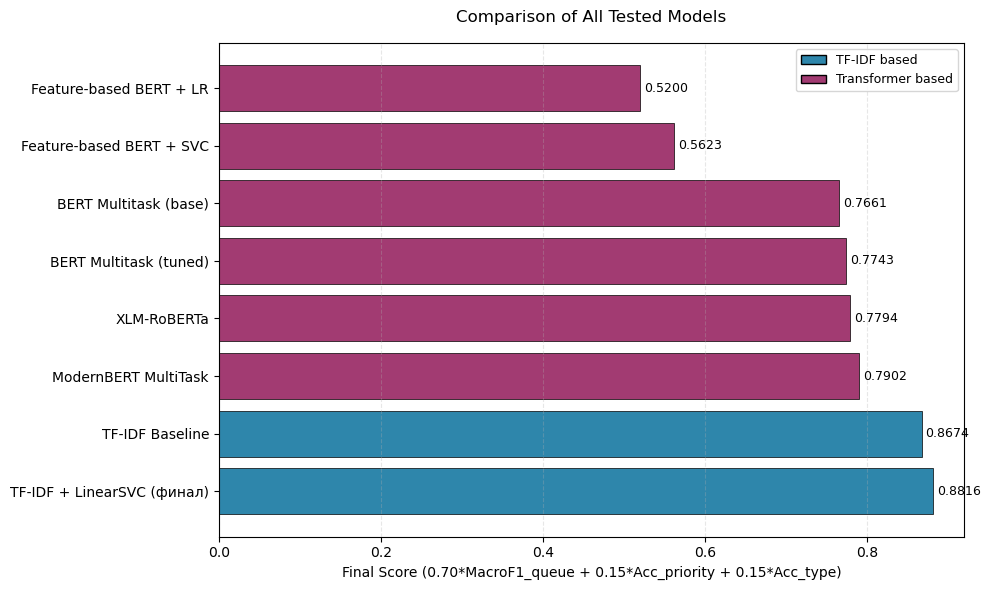

In [9]:
models = [
    "TF-IDF + LinearSVC (финал)",
    "TF-IDF Baseline",
    "ModernBERT MultiTask",
    "XLM-RoBERTa",
    "BERT Multitask (tuned)",
    "BERT Multitask (base)",
    "Feature-based BERT + SVC",
    "Feature-based BERT + LR"
]

scores = [
    0.8816,
    0.8674,
    0.7902,
    0.7794,
    0.7743,
    0.7661,
    0.5623,
    0.5200
]
method_types = [
    "TF-IDF", "TF-IDF", 
    "Transformer", "Transformer", "Transformer", "Transformer",
    "Transformer", "Transformer"
]

# Цвета для разных подходов
colors = {"TF-IDF": "#2E86AB", "Transformer": "#A23B72"}
bar_colors = [colors[t] for t in method_types]

plt.figure(figsize=(10, 6))
bars = plt.barh(models, scores, color=bar_colors, edgecolor="black", linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
             f"{width:.4f}", va="center", fontsize=9)

plt.xlabel("Final Score", fontsize=10)
plt.title("Comparison of All Tested Models", fontsize=12, pad=15)
plt.xlim(0, 0.92)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2E86AB", edgecolor="black", label="TF-IDF based"),
    Patch(facecolor="#A23B72", edgecolor="black", label="Transformer based")
]
plt.legend(handles=legend_elements, fontsize=9)

plt.show()

In [10]:
results = pd.DataFrame({
    'Model': [
        "TF-IDF + LinearSVC (финал)",
        "TF-IDF Baseline",
        "ModernBERT MultiTask",
        "XLM-RoBERTa",
        "BERT Multitask (tuned)",
        "BERT Multitask (base)",
        "Feature-based BERT + SVC",
        "Feature-based BERT + LR"
    ],
    'Final_Score': [
        0.8816, 0.8674, 0.7902, 0.7794, 
        0.7743, 0.7661, 0.5623, 0.5200
    ]
})

results = results.sort_values('Final_Score', ascending=False).reset_index(drop=True)

display(results)

,Model,Final_Score
0,TF-IDF + LinearSVC (финал),0.8816
1,TF-IDF Baseline,0.8674
2,ModernBERT MultiTask,0.7902
3,XLM-RoBERTa,0.7794
4,BERT Multitask (tuned),0.7743
5,BERT Multitask (base),0.7661
6,Feature-based BERT + SVC,0.5623
7,Feature-based BERT + LR,0.5200
